In [1]:
import os
import pandas as pd
from pathlib import Path

In [2]:
BASE = Path(r"C:\Users\potot\OneDrive\Documentos\DEEP\ai4mars-dataset-merged-0.6")

In [3]:
def canonical_name(name):
    name = name.replace("_0LLJ", "")
    
    # eliminar sufijos merged
    for i in range(1, 100):
        name = name.replace(f"_merged{i}", "")
    
    return name

In [4]:
def build_manifest(image_dir, label_dir, mission, camera):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    images = {}
    for img in image_dir.iterdir():
        if img.suffix.lower() in [".jpg", ".jpeg"]:
            key = canonical_name(img.stem)
            
            # priorizar jpeg sobre jpg
            if key not in images or img.suffix.lower() == ".jpeg":
                images[key] = img

    labels = {}
    for lbl in label_dir.iterdir():
        if lbl.suffix.lower() == ".png":
            key = canonical_name(lbl.stem)
            labels[key] = lbl

    # intersección segura
    keys = set(images.keys()) & set(labels.keys())

    rows = []
    for k in keys:
        rows.append({
            "mission": mission,
            "camera": camera,
            "id": k,
            "image_path": str(images[k]),
            "mask_path": str(labels[k])
        })

    return pd.DataFrame(rows)

In [5]:
msl_df = build_manifest(
    BASE / "msl" / "ncam" / "images" / "edr",
    BASE / "msl" / "ncam" / "labels" / "train",
    mission="MSL",
    camera="ncam"
)

In [6]:
mer_df = build_manifest(
    BASE / "mer" / "images" / "eff",
    BASE / "mer" / "labels" / "train" / "merged-unmasked",
    mission="MER",
    camera="ncam"
)

In [7]:
m2020_df = build_manifest(
    BASE / "m2020" / "images" / "ncam",
    BASE / "m2020" / "labels" / "NAV",
    mission="M2020",
    camera="ncam"
)

In [8]:
df = pd.concat([msl_df, mer_df, m2020_df], ignore_index=True)

In [9]:
print("Total samples:", len(df))
print(df["mission"].value_counts())

Total samples: 23928
mission
MSL      16064
MER       7391
M2020      473
Name: count, dtype: int64


In [10]:
output_path = Path("processed/manifest.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False)

In [11]:
import numpy as np
from PIL import Image
from tqdm import tqdm

def check_masks(df):
    empty_masks = []
    only_ignore = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        mask = np.array(Image.open(row["mask_path"]))
        
        unique = np.unique(mask)
        
        # máscara completamente vacía
        if len(unique) == 1:
            empty_masks.append(idx)
        
        # solo 255 (ignore)
        if set(unique) == {255}:
            only_ignore.append(idx)
    
    return empty_masks, only_ignore


empty_masks, only_ignore = check_masks(df)

print("Máscaras vacías:", len(empty_masks))
print("Solo 255:", len(only_ignore))

  0%|          | 10/23928 [00:00<08:20, 47.82it/s]

100%|██████████| 23928/23928 [04:47<00:00, 83.22it/s] 

Máscaras vacías: 963
Solo 255: 963


In [12]:
bad_indices = set(empty_masks) | set(only_ignore)

df_clean = df.drop(index=bad_indices).reset_index(drop=True)

print("Antes:", len(df))
print("Después:", len(df_clean))

Antes: 23928
Después: 22965


In [13]:
def check_sizes(df, sample=200):
    sizes = []
    
    sample_df = df.sample(min(sample, len(df)))
    
    for _, row in sample_df.iterrows():
        img = Image.open(row["image_path"])
        sizes.append(img.size)  # (width, height)
    
    return sizes


sizes = check_sizes(df_clean)

print(set(sizes))

{(1288, 968), (1024, 1024)}


In [14]:
df_clean.to_csv("processed/manifest_clean.csv", index=False)

In [15]:
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

def class_distribution(df, sample_size=500):
    counts = defaultdict(int)
    total = 0
    
    sample_df = df.sample(min(sample_size, len(df)), random_state=42)
    
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        mask = np.array(Image.open(row["mask_path"]))
        unique, c = np.unique(mask, return_counts=True)
        
        for u, cc in zip(unique, c):
            counts[int(u)] += int(cc)
            total += int(cc)
    
    dist = {k: v/total for k, v in counts.items()}
    return dict(sorted(dist.items()))
    

dist_global = class_distribution(df_clean, sample_size=500)

print("Distribución global:")
for k, v in dist_global.items():
    print(f"Clase {k}: {v:.4f}")

100%|██████████| 500/500 [00:06<00:00, 82.29it/s]

Distribución global:
Clase 0: 0.2155
Clase 1: 0.2349
Clase 2: 0.1022
Clase 3: 0.0050
Clase 255: 0.4424


In [16]:
def class_distribution_by_mission(df):
    results = {}
    
    for mission in df["mission"].unique():
        df_m = df[df["mission"] == mission]
        dist = class_distribution(df_m, sample_size=200)
        results[mission] = dist
    
    return results


dist_by_mission = class_distribution_by_mission(df_clean)

for mission, dist in dist_by_mission.items():
    print(f"\n--- {mission} ---")
    for k, v in dist.items():
        print(f"Clase {k}: {v:.4f}")

100%|██████████| 200/200 [00:01<00:00, 115.82it/s]


--- MSL ---
Clase 0: 0.2125
Clase 1: 0.2748
Clase 2: 0.0732
Clase 3: 0.0034
Clase 255: 0.4361

--- MER ---
Clase 0: 0.2717
Clase 1: 0.1204
Clase 2: 0.1994
Clase 3: 0.0044
Clase 255: 0.4041

--- M2020 ---
Clase 0: 0.1577
Clase 1: 0.0949
Clase 2: 0.0476
Clase 3: 0.0162
Clase 255: 0.6835


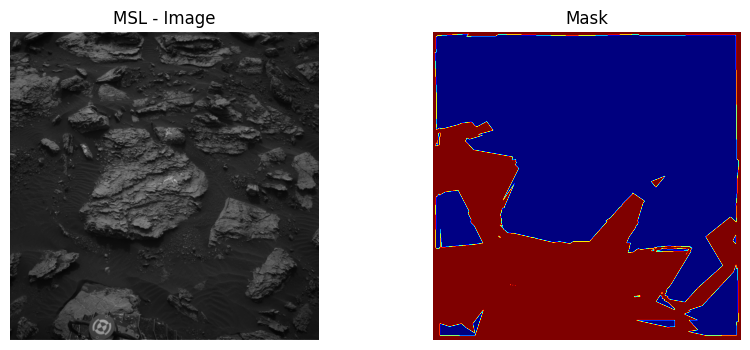

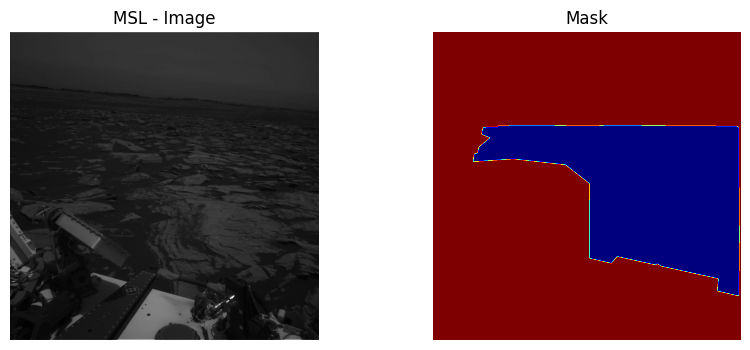

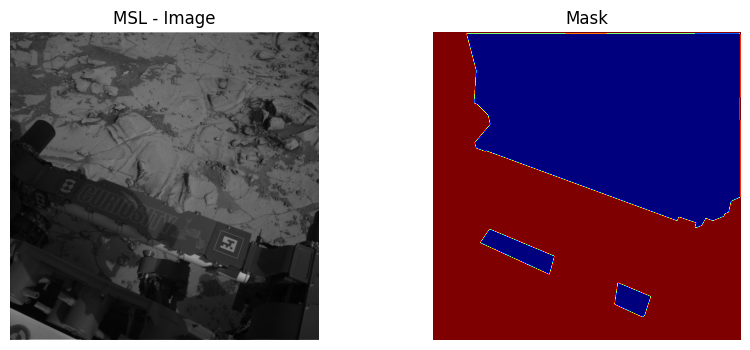

In [17]:
import matplotlib.pyplot as plt

def show_sample(df):
    row = df.sample(1).iloc[0]
    
    img = Image.open(row["image_path"])
    mask = np.array(Image.open(row["mask_path"]))
    
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{row['mission']} - Image")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='jet')
    plt.title("Mask")
    plt.axis('off')
    
    plt.show()


for _ in range(3):
    show_sample(df_clean)

In [18]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import defaultdict
 
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [19]:
LABEL_MAP = {
    0: "soil",
    1: "bedrock",
    2: "sand",
    3: "big_rock",
    255: "ignore",
}
 
NUM_CLASSES = 4   # 0-3; 255 se maneja con ignore_index

In [20]:
def get_train_transforms(img_size: int = 256):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=(0.485,), std=(0.229,)),   # grayscale → 1 canal
        ToTensorV2(),
    ])
 
def get_val_transforms(img_size: int = 256):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485,), std=(0.229,)),
        ToTensorV2(),
    ])

In [21]:
class MarsDataset(Dataset):
    """
    Parámetros
    ----------
    df          : DataFrame con columnas [image_path, mask_path, mission, camera, id]
    transforms  : albumentations Compose
    img_size    : tamaño destino (cuadrado)
    """
 
    def __init__(self, df: pd.DataFrame, transforms=None, img_size: int = 256):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.img_size = img_size
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
 
        # --- imagen (grayscale → RGB para compatibilidad con encoders ImageNet) ---
        img = np.array(Image.open(row["image_path"]).convert("RGB"))
 
        # --- máscara ---
        mask = np.array(Image.open(row["mask_path"]))
 
        # albumentations espera HxWxC para imagen, HxW para máscara
        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img  = augmented["image"]   # Tensor [C, H, W]
            mask = augmented["mask"]    # Tensor [H, W]
        else:
            img  = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask)
 
        mask = mask.long()   # CrossEntropyLoss requiere LongTensor
 
        return img, mask, row["mission"]

In [22]:
def split_manifest(
    df: pd.DataFrame,
    train_ratio: float = 0.70,
    val_ratio:   float = 0.15,
    # test_ratio implícito: 1 - train - val
    seed: int = 42,
    stratify_by: str = "mission",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split estratificado por misión para evitar que M2020 (minoría)
    quede fuera del test set.
    """
    from sklearn.model_selection import train_test_split
 
    test_ratio = 1.0 - train_ratio - val_ratio
 
    train_frames, val_frames, test_frames = [], [], []
 
    for mission, group in df.groupby(stratify_by):
        g = group.sample(frac=1, random_state=seed)   # shuffle
 
        n = len(g)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)
 
        train_frames.append(g.iloc[:n_train])
        val_frames.append(  g.iloc[n_train : n_train + n_val])
        test_frames.append( g.iloc[n_train + n_val :])
 
    df_train = pd.concat(train_frames).sample(frac=1, random_state=seed).reset_index(drop=True)
    df_val   = pd.concat(val_frames  ).sample(frac=1, random_state=seed).reset_index(drop=True)
    df_test  = pd.concat(test_frames ).sample(frac=1, random_state=seed).reset_index(drop=True)
 
    print(f"Train : {len(df_train):>6}  {df_train['mission'].value_counts().to_dict()}")
    print(f"Val   : {len(df_val):>6}  {df_val['mission'].value_counts().to_dict()}")
    print(f"Test  : {len(df_test):>6}  {df_test['mission'].value_counts().to_dict()}")
 
    return df_train, df_val, df_test

In [23]:
def make_weighted_sampler(df: pd.DataFrame) -> WeightedRandomSampler:
    """
    Asigna a cada sample un peso inversamente proporcional
    al tamaño de su misión → cada misión tiene igual probabilidad
    de aparecer en cada batch.
    """
    mission_counts = df["mission"].value_counts().to_dict()
    weights = df["mission"].map(lambda m: 1.0 / mission_counts[m]).values
    weights = torch.DoubleTensor(weights)
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    return sampler

In [24]:
def compute_class_weights(
    dist: dict,
    num_classes: int = NUM_CLASSES,
    device: str = "cpu"
) -> torch.Tensor:
    """
    dist: {clase: fracción} tal como devuelve class_distribution()
          (ignora clave 255)
    Devuelve tensor [num_classes] con 1/freq normalizado.
    """
    freqs = np.array([dist.get(c, 1e-6) for c in range(num_classes)], dtype=np.float32)
    weights = 1.0 / freqs
    weights = weights / weights.sum()   # normalizar
    return torch.tensor(weights, dtype=torch.float32, device=device)


In [25]:
def build_dataloaders(
    df_train: pd.DataFrame,
    df_val:   pd.DataFrame,
    df_test:  pd.DataFrame,
    img_size:    int  = 256,
    batch_size:  int  = 16,
    num_workers: int  = 4,
    balance_missions: bool = True,
) -> tuple[DataLoader, DataLoader, DataLoader]:
 
    train_ds = MarsDataset(df_train, transforms=get_train_transforms(img_size), img_size=img_size)
    val_ds   = MarsDataset(df_val,   transforms=get_val_transforms(img_size),   img_size=img_size)
    test_ds  = MarsDataset(df_test,  transforms=get_val_transforms(img_size),   img_size=img_size)
 
    sampler = make_weighted_sampler(df_train) if balance_missions else None
 
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        shuffle=(sampler is None),
        num_workers=num_workers,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
 
    return train_loader, val_loader, test_loader

In [26]:
if __name__ == "__main__":
    manifest = pd.read_csv("processed/manifest_clean.csv")
    print(f"Total muestras: {len(manifest)}")
 
    df_train, df_val, df_test = split_manifest(manifest)
 
    train_loader, val_loader, test_loader = build_dataloaders(
        df_train, df_val, df_test,
        img_size=256,
        batch_size=8,
        num_workers=0,       # 0 para debug local
        balance_missions=True,
    )
 
    # verificar un batch
    imgs, masks, missions = next(iter(train_loader))
    print(f"\nBatch shape  → imgs: {imgs.shape}  masks: {masks.shape}")
    print(f"Misiones en batch: {list(missions)}")
    print(f"Valores únicos en máscara: {masks.unique().tolist()}")
    print("\n✅ Dataset listo para entrenamiento.")

Total muestras: 22965
Train :  16074  {'MSL': 11130, 'MER': 4615, 'M2020': 329}
Val   :   3443  {'MSL': 2385, 'MER': 988, 'M2020': 70}
Test  :   3448  {'MSL': 2386, 'MER': 990, 'M2020': 72}

Batch shape  → imgs: torch.Size([8, 3, 256, 256])  masks: torch.Size([8, 256, 256])
Misiones en batch: ['MER', 'MSL', 'M2020', 'MSL', 'MER', 'M2020', 'MSL', 'MSL']
Valores únicos en máscara: [0, 1, 2, 255]

✅ Dataset listo para entrenamiento.


EDA

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
import hashlib
import warnings
warnings.filterwarnings("ignore")

In [28]:
CLASS_COLORS = {
    0: ("#E69F00", "soil"),
    1: ("#56B4E9", "bedrock"),
    2: ("#009E73", "sand"),
    3: ("#D55E00", "big_rock"),
    255: ("#999999", "ignore"),
}
 
MISSION_COLORS = {"MSL": "#0072B2", "MER": "#CC79A7", "M2020": "#F0E442"}

In [29]:
df_clean = pd.read_csv("processed/manifest_clean.csv")
print(f"Total muestras limpias: {len(df_clean)}")
print(df_clean["mission"].value_counts())

Total muestras limpias: 22965
mission
MSL      15901
MER       6593
M2020      471
Name: count, dtype: int64


Contando píxeles: 100%|██████████| 600/600 [00:08<00:00, 74.65it/s]


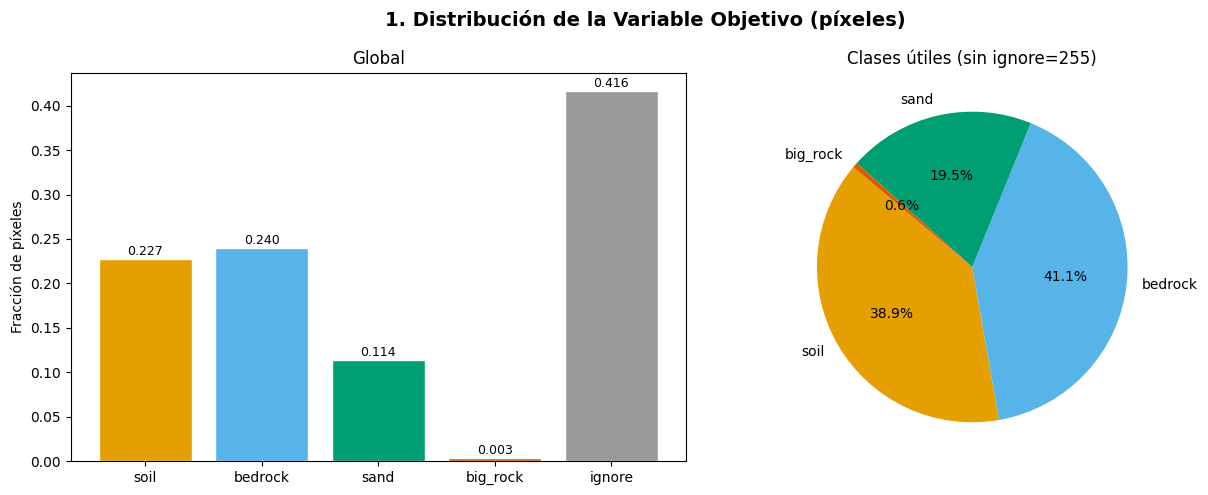


Ratio de desbalance (clase dominante / clase rara): 74.2x
  → Clase más frecuente : bedrock (41.09%)
  → Clase más rara      : big_rock (0.55%)

──────────────────────────────────────────────────────────
[D] Decisión: usar CrossEntropyLoss(ignore_index=255) + class_weights
    inversamente proporcionales a frecuencia (big_rock ~50x más peso).
    Considerar Focal Loss como alternativa (γ=2).
[A] Impacto: la cabeza de clasificación debe tener 4 salidas (no 5).
    La métrica principal será mIoU excluyendo clase 255.
[R] Riesgo: accuracy de píxeles es engañosa (~45% son ignore).
    No usar pixel accuracy como métrica principal.
──────────────────────────────────────────────────────────



In [30]:
def pixel_class_counts(df, sample_n=600, seed=42):
    """Cuenta píxeles por clase sobre un sample del dataset."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample_n, len(df)), replace=False)
    counts = defaultdict(int)
    for i in tqdm(idx, desc="Contando píxeles"):
        mask = np.array(Image.open(df.iloc[i]["mask_path"]))
        vals, cnts = np.unique(mask, return_counts=True)
        for v, c in zip(vals, cnts):
            counts[int(v)] += int(c)
    return counts
 
counts_global = pixel_class_counts(df_clean, sample_n=600)
total_px = sum(counts_global.values())
 
labels_order = [0, 1, 2, 3, 255]
fracs   = [counts_global.get(c, 0) / total_px for c in labels_order]
colors  = [CLASS_COLORS[c][0] for c in labels_order]
names   = [CLASS_COLORS[c][1] for c in labels_order]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("1. Distribución de la Variable Objetivo (píxeles)", fontsize=14, fontweight="bold")
 
# Barras
axes[0].bar(names, fracs, color=colors, edgecolor="white")
axes[0].set_ylabel("Fracción de píxeles")
axes[0].set_title("Global")
for i, (n, f) in enumerate(zip(names, fracs)):
    axes[0].text(i, f + 0.005, f"{f:.3f}", ha="center", fontsize=9)
 
# Pie sin ignore para ver clases útiles
fracs_no_ign = [counts_global.get(c, 0) for c in [0,1,2,3]]
names_no_ign = [CLASS_COLORS[c][1] for c in [0,1,2,3]]
colors_no_ign = [CLASS_COLORS[c][0] for c in [0,1,2,3]]
axes[1].pie(fracs_no_ign, labels=names_no_ign, colors=colors_no_ign,
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Clases útiles (sin ignore=255)")
 
plt.tight_layout()
plt.savefig("processed/eda_01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Ratio de desbalance
valid = {c: counts_global.get(c,0) for c in [0,1,2,3]}
max_c = max(valid, key=valid.get)
min_c = min(valid, key=valid.get)
ratio = valid[max_c] / max(valid[min_c], 1)
print(f"\nRatio de desbalance (clase dominante / clase rara): {ratio:.1f}x")
print(f"  → Clase más frecuente : {CLASS_COLORS[max_c][1]} ({valid[max_c]/sum(valid.values()):.2%})")
print(f"  → Clase más rara      : {CLASS_COLORS[min_c][1]} ({valid[min_c]/sum(valid.values()):.2%})")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: usar CrossEntropyLoss(ignore_index=255) + class_weights
    inversamente proporcionales a frecuencia (big_rock ~50x más peso).
    Considerar Focal Loss como alternativa (γ=2).
[A] Impacto: la cabeza de clasificación debe tener 4 salidas (no 5).
    La métrica principal será mIoU excluyendo clase 255.
[R] Riesgo: accuracy de píxeles es engañosa (~45% son ignore).
    No usar pixel accuracy como métrica principal.
──────────────────────────────────────────────────────────
""")


Calculando distribución por misión...


  MSL: 100%|██████████| 200/200 [00:02<00:00, 83.35it/s]


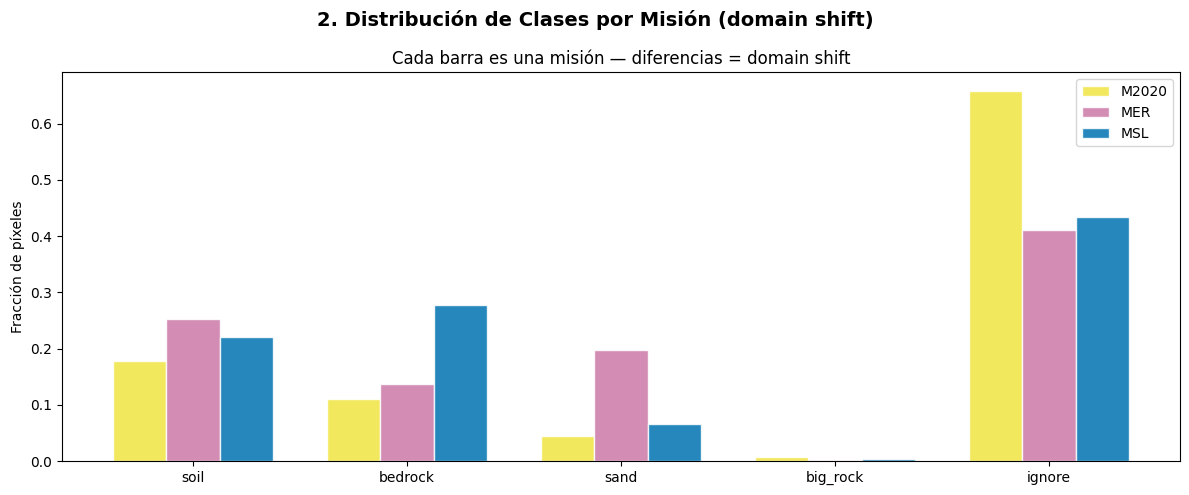


──────────────────────────────────────────────────────────
[D] Decisión: split ESTRATIFICADO por misión para que train/val/test
    reflejen la distribución real. No mezclar misiones en val/test
    sin control.
[A] Impacto: el modelo debe ser evaluado POR MISIÓN, no solo global.
    Considerar experimento cross-mission (train MSL+MER, test M2020).
[R] Riesgo de domain shift: un modelo entrenado principalmente en MSL
    puede colapsar en M2020 (64% ignore, distribución completamente
    distinta). Esto es data leakage implícito si no se controla.
──────────────────────────────────────────────────────────



In [31]:
def pixel_counts_by_mission(df, sample_per_mission=200, seed=42):
    results = {}
    for mission, group in df.groupby("mission"):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(group), size=min(sample_per_mission, len(group)), replace=False)
        counts = defaultdict(int)
        for i in tqdm(idx, desc=f"  {mission}"):
            mask = np.array(Image.open(group.iloc[i]["mask_path"]))
            vals, cnts = np.unique(mask, return_counts=True)
            for v, c in zip(vals, cnts):
                counts[int(v)] += int(c)
        total = sum(counts.values())
        results[mission] = {k: v/total for k, v in counts.items()}
    return results
 
print("\nCalculando distribución por misión...")
dist_mission = pixel_counts_by_mission(df_clean, sample_per_mission=200)
 
missions = list(dist_mission.keys())
x = np.arange(len([0,1,2,3,255]))
width = 0.25
 
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("2. Distribución de Clases por Misión (domain shift)", fontsize=14, fontweight="bold")
 
for i, mission in enumerate(missions):
    dist = dist_mission[mission]
    vals = [dist.get(c, 0) for c in [0,1,2,3,255]]
    bars = ax.bar(x + i*width, vals, width, label=mission,
                  color=MISSION_COLORS[mission], edgecolor="white", alpha=0.85)
 
ax.set_xticks(x + width)
ax.set_xticklabels([CLASS_COLORS[c][1] for c in [0,1,2,3,255]])
ax.set_ylabel("Fracción de píxeles")
ax.legend()
ax.set_title("Cada barra es una misión — diferencias = domain shift")
plt.tight_layout()
plt.savefig("processed/eda_02_class_by_mission.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: split ESTRATIFICADO por misión para que train/val/test
    reflejen la distribución real. No mezclar misiones en val/test
    sin control.
[A] Impacto: el modelo debe ser evaluado POR MISIÓN, no solo global.
    Considerar experimento cross-mission (train MSL+MER, test M2020).
[R] Riesgo de domain shift: un modelo entrenado principalmente en MSL
    puede colapsar en M2020 (64% ignore, distribución completamente
    distinta). Esto es data leakage implícito si no se controla.
──────────────────────────────────────────────────────────
""")


Analizando tamaños...


Midiendo imágenes: 100%|██████████| 500/500 [00:00<00:00, 1003.28it/s]


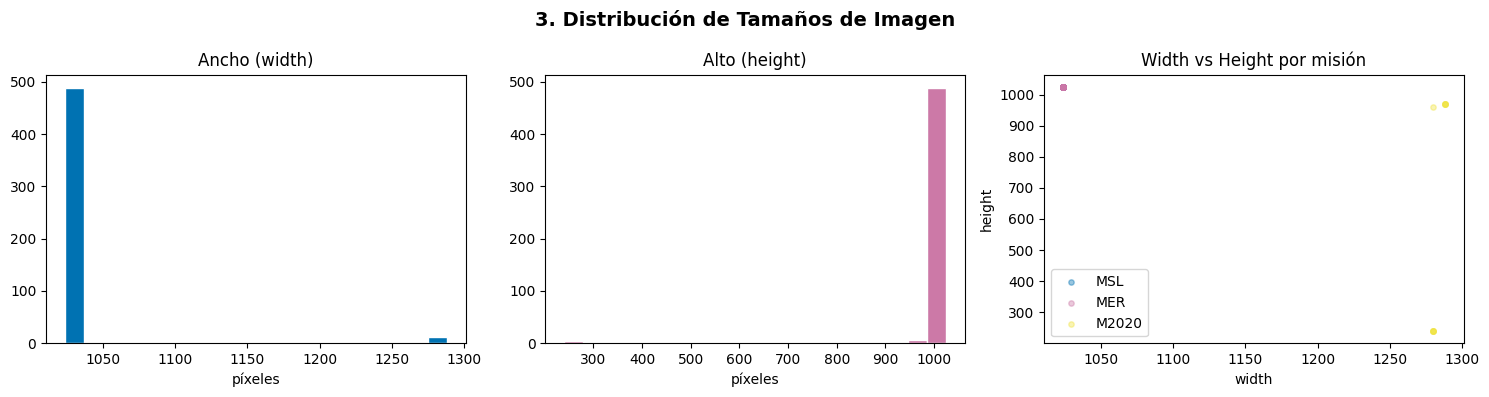

Tamaños más frecuentes:
(1024, 1024)    489
(1288, 968)       5
(1280, 240)       5
(1280, 960)       1

──────────────────────────────────────────────────────────
[D] Decisión: resize a 256×256 (o 512×512 si hay GPU suficiente).
    Aspect ratio varía mucho → resize sin mantener proporción es
    aceptable dado que las máscaras deben resizarse igual.
    Normalización: mean=0.485, std=0.229 (grayscale como 1 canal).
[A] Impacto: todos los modelos recibirán input fijo [B, 3, 256, 256]
    (3 canales por compatibilidad con encoders ImageNet).
[R] Riesgo: imágenes muy rectangulares (1280×240) pierden información
    geométrica al hacer resize cuadrado. Documentar como limitación.
──────────────────────────────────────────────────────────



In [32]:
def get_all_sizes(df, sample_n=500, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample_n, len(df)), replace=False)
    sizes = []
    missions = []
    for i in tqdm(idx, desc="Midiendo imágenes"):
        row = df.iloc[i]
        img = Image.open(row["image_path"])
        sizes.append(img.size)   # (width, height)
        missions.append(row["mission"])
    return sizes, missions
 
print("\nAnalizando tamaños...")
sizes, size_missions = get_all_sizes(df_clean, sample_n=500)
widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("3. Distribución de Tamaños de Imagen", fontsize=14, fontweight="bold")
 
axes[0].hist(widths,  bins=20, color="#0072B2", edgecolor="white")
axes[0].set_title("Ancho (width)")
axes[0].set_xlabel("píxeles")
 
axes[1].hist(heights, bins=20, color="#CC79A7", edgecolor="white")
axes[1].set_title("Alto (height)")
axes[1].set_xlabel("píxeles")
 
# scatter por misión
for m, color in MISSION_COLORS.items():
    wx = [widths[i]  for i, ms in enumerate(size_missions) if ms == m]
    hy = [heights[i] for i, ms in enumerate(size_missions) if ms == m]
    axes[2].scatter(wx, hy, label=m, alpha=0.4, s=15, color=color)
axes[2].set_xlabel("width"); axes[2].set_ylabel("height")
axes[2].set_title("Width vs Height por misión")
axes[2].legend()
 
plt.tight_layout()
plt.savefig("processed/eda_03_image_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
 
unique_sizes = pd.Series(sizes).value_counts()
print("Tamaños más frecuentes:")
print(unique_sizes.head(8).to_string())
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: resize a 256×256 (o 512×512 si hay GPU suficiente).
    Aspect ratio varía mucho → resize sin mantener proporción es
    aceptable dado que las máscaras deben resizarse igual.
    Normalización: mean=0.485, std=0.229 (grayscale como 1 canal).
[A] Impacto: todos los modelos recibirán input fijo [B, 3, 256, 256]
    (3 canales por compatibilidad con encoders ImageNet).
[R] Riesgo: imágenes muy rectangulares (1280×240) pierden información
    geométrica al hacer resize cuadrado. Documentar como limitación.
──────────────────────────────────────────────────────────
""")


Analizando intensidades...


Intensidades: 100%|██████████| 300/300 [00:02<00:00, 115.52it/s]


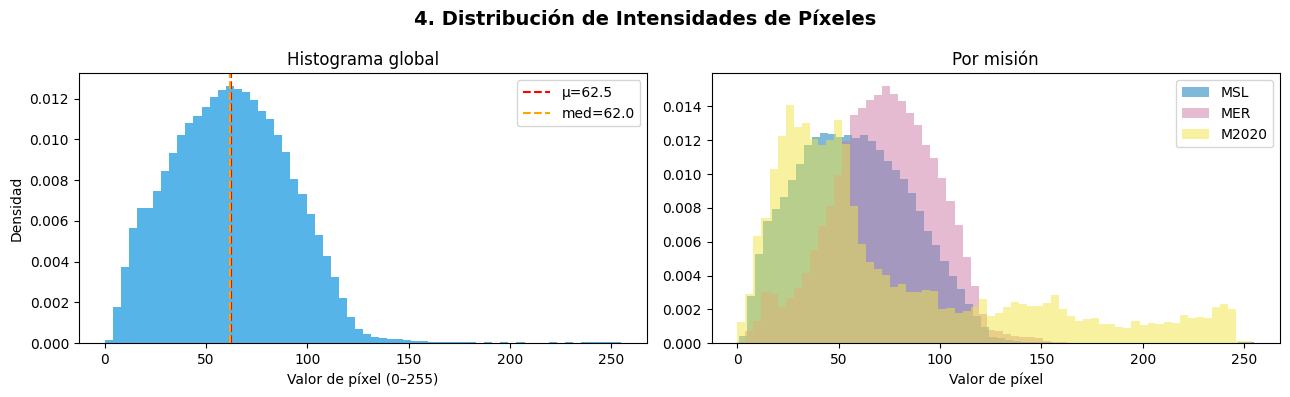

Media global: 62.49  |  Std: 29.59
Min: 0  |  Max: 255
Píxeles muy oscuros (<10): 1.40%
Píxeles saturados (>245): 0.04%

──────────────────────────────────────────────────────────
[D] Decisión: normalizar con media y std calculadas sobre TRAIN
    solamente (no sobre val/test → evita data leakage).
    Usar: mean ≈ 0.45, std ≈ 0.22 (escala 0-1) como aproximación
    o calcular exacto sobre train set.
[A] Impacto: si se usa backbone ImageNet (3 canales), replicar canal
    grayscale 3 veces y usar stats de ImageNet es válido y habitual.
[R] Riesgo CRÍTICO de data leakage: si se normaliza con stats del
    dataset completo antes del split, el test set "conoce" la
    distribución de train. Stats deben calcularse SOLO en train.
──────────────────────────────────────────────────────────



In [33]:
def pixel_intensity_stats(df, sample_n=300, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample_n, len(df)), replace=False)
    all_pixels = []
    per_mission = defaultdict(list)
    for i in tqdm(idx, desc="Intensidades"):
        row = df.iloc[i]
        img = np.array(Image.open(row["image_path"]).convert("L")).flatten()
        sample_px = img[rng.choice(len(img), size=min(2000, len(img)), replace=False)]
        all_pixels.extend(sample_px.tolist())
        per_mission[row["mission"]].extend(sample_px.tolist())
    return all_pixels, per_mission
 
print("\nAnalizando intensidades...")
all_px, px_mission = pixel_intensity_stats(df_clean, sample_n=300)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("4. Distribución de Intensidades de Píxeles", fontsize=14, fontweight="bold")
 
axes[0].hist(all_px, bins=64, color="#56B4E9", edgecolor="none", density=True)
axes[0].set_title("Histograma global")
axes[0].set_xlabel("Valor de píxel (0–255)")
axes[0].set_ylabel("Densidad")
axes[0].axvline(np.mean(all_px),  color="red",    linestyle="--", label=f"μ={np.mean(all_px):.1f}")
axes[0].axvline(np.median(all_px), color="orange", linestyle="--", label=f"med={np.median(all_px):.1f}")
axes[0].legend()
 
for m, color in MISSION_COLORS.items():
    if m in px_mission:
        axes[1].hist(px_mission[m], bins=64, color=color, alpha=0.5,
                     density=True, label=m, edgecolor="none")
axes[1].set_title("Por misión")
axes[1].set_xlabel("Valor de píxel")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("processed/eda_04_pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"Media global: {np.mean(all_px):.2f}  |  Std: {np.std(all_px):.2f}")
print(f"Min: {np.min(all_px)}  |  Max: {np.max(all_px)}")
sat_low  = np.mean(np.array(all_px) < 10)
sat_high = np.mean(np.array(all_px) > 245)
print(f"Píxeles muy oscuros (<10): {sat_low:.2%}")
print(f"Píxeles saturados (>245): {sat_high:.2%}")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: normalizar con media y std calculadas sobre TRAIN
    solamente (no sobre val/test → evita data leakage).
    Usar: mean ≈ 0.45, std ≈ 0.22 (escala 0-1) como aproximación
    o calcular exacto sobre train set.
[A] Impacto: si se usa backbone ImageNet (3 canales), replicar canal
    grayscale 3 veces y usar stats de ImageNet es válido y habitual.
[R] Riesgo CRÍTICO de data leakage: si se normaliza con stats del
    dataset completo antes del split, el test set "conoce" la
    distribución de train. Stats deben calcularse SOLO en train.
──────────────────────────────────────────────────────────
""")

In [34]:
def fast_image_hash(path, size=(32, 32)):
    """Hash rápido basado en thumbnail — detecta duplicados exactos."""
    img = Image.open(path).convert("L").resize(size)
    return hashlib.md5(np.array(img).tobytes()).hexdigest()
 
print("\nDetectando duplicados (sample 1000)...")
sample_df = df_clean.sample(min(1000, len(df_clean)), random_state=42)
hashes = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    try:
        h = fast_image_hash(row["image_path"])
    except Exception:
        h = "error"
    hashes.append(h)
 
sample_df = sample_df.copy()
sample_df["img_hash"] = hashes
duplicates = sample_df[sample_df.duplicated("img_hash", keep=False)]
 
print(f"Imágenes duplicadas encontradas (en sample 1000): {len(duplicates)}")
if len(duplicates) > 0:
    print(duplicates[["mission", "id", "img_hash"]].head(10))
else:
    print("✅ No se detectaron duplicados exactos en el sample.")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: si hay duplicados cross-misión, eliminarlos antes
    del split. Si son dentro de misión, documentar pero pueden
    mantenerse (son condiciones distintas de captura).
[A] Impacto: duplicados en train y test generan overfitting
    artificialmente inflado → métricas no representan generalización.
[R] Riesgo CRÍTICO: duplicados entre train y test = data leakage
    directo. El modelo "memoriza" imágenes que luego aparecen en test.
──────────────────────────────────────────────────────────
""")


Detectando duplicados (sample 1000)...


100%|██████████| 1000/1000 [00:07<00:00, 129.01it/s]

Imágenes duplicadas encontradas (en sample 1000): 0
✅ No se detectaron duplicados exactos en el sample.

──────────────────────────────────────────────────────────
[D] Decisión: si hay duplicados cross-misión, eliminarlos antes
    del split. Si son dentro de misión, documentar pero pueden
    mantenerse (son condiciones distintas de captura).
[A] Impacto: duplicados en train y test generan overfitting
    artificialmente inflado → métricas no representan generalización.
[R] Riesgo CRÍTICO: duplicados entre train y test = data leakage
    directo. El modelo "memoriza" imágenes que luego aparecen en test.
──────────────────────────────────────────────────────────



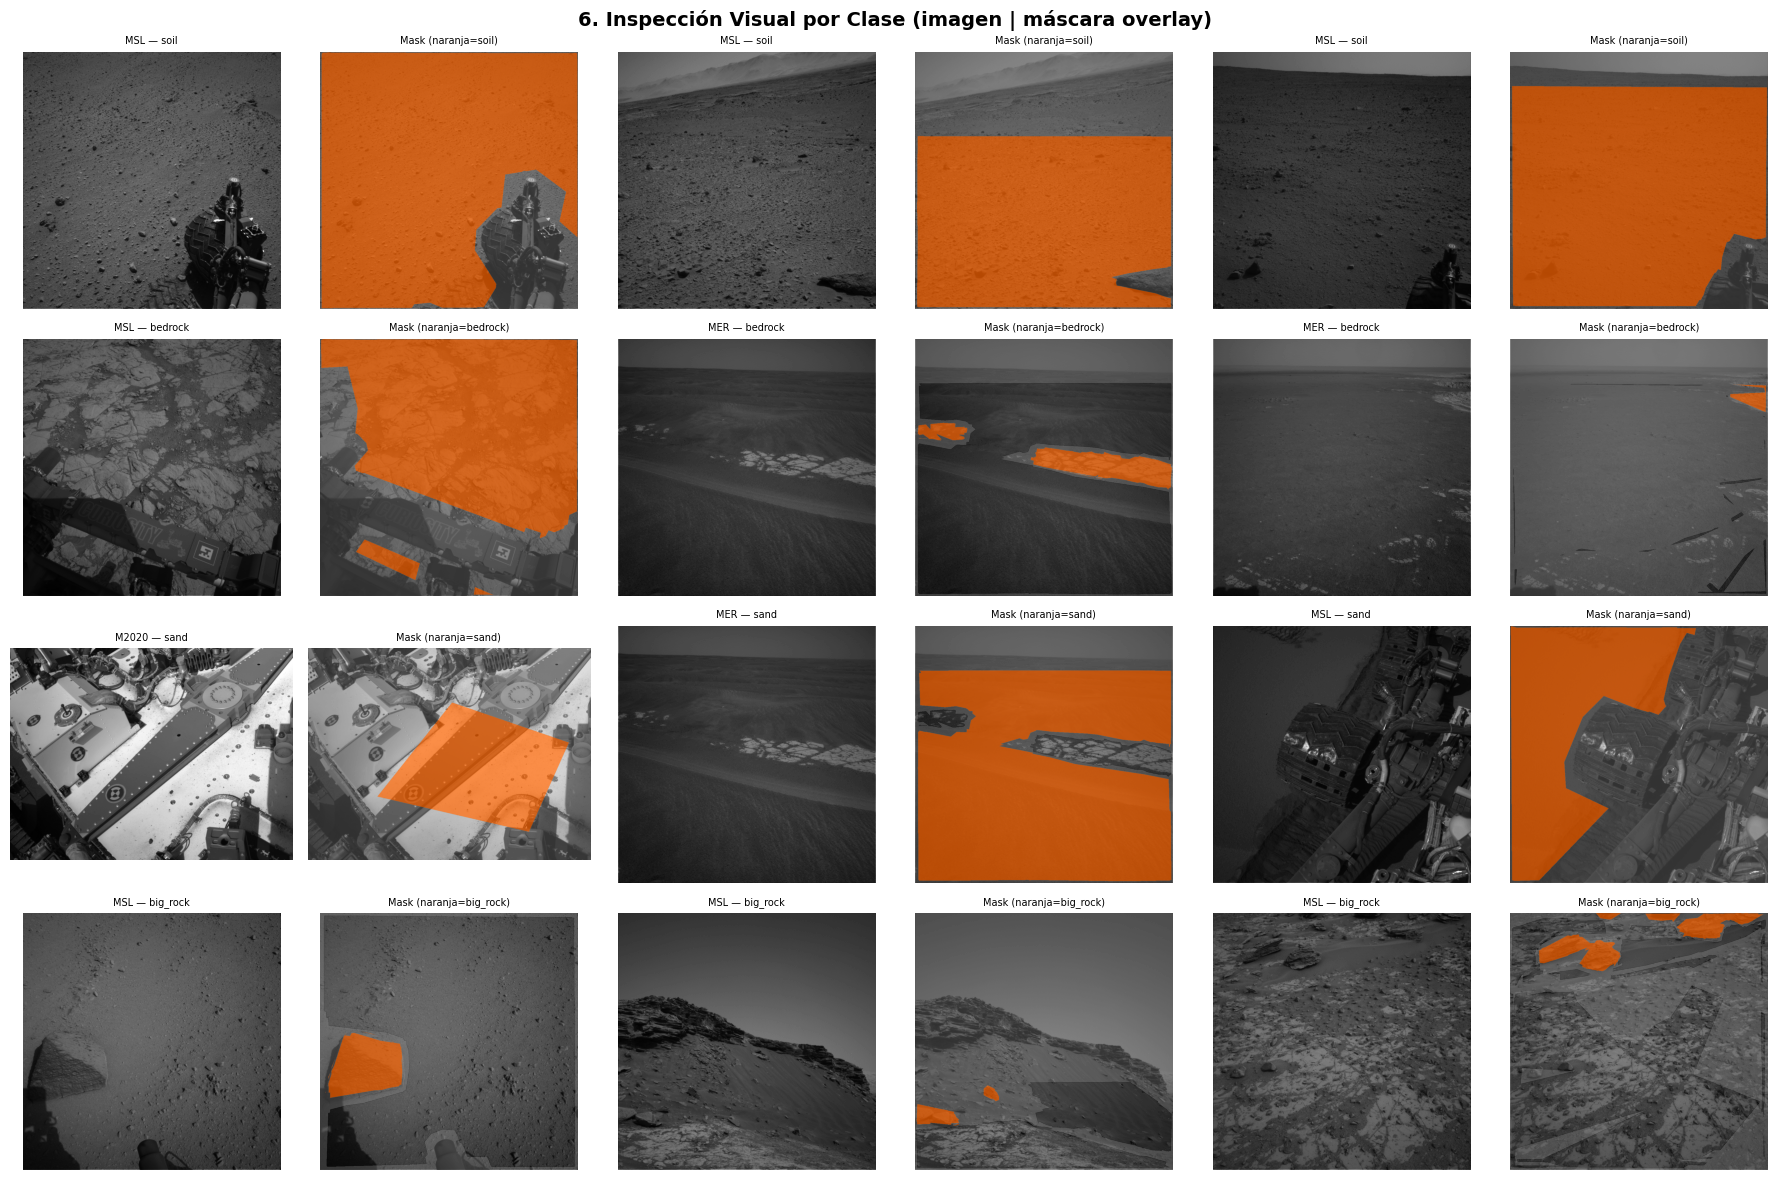


──────────────────────────────────────────────────────────
[D] Decisión: las máscaras muestran bordes irregulares y regiones
    ignore extensas → no usar técnicas de crop aleatorio agresivo
    que puedan eliminar las pocas instancias de big_rock.
    Usar HorizontalFlip + RandomBrightnessContrast como augmentaciones
    seguras. Evitar rotaciones grandes (distorsión geométrica relevante).
[A] Impacto: arquitecturas con receptive field grande (UNet, DeepLab)
    son preferibles a FCN puro dado el contexto espacial amplio.
[R] Riesgo: errores de etiquetado visibles en bordes de máscara.
    Documentar como ruido estructural del dataset (no del modelo).
──────────────────────────────────────────────────────────



In [35]:
def find_samples_with_class(df, class_id, n=3, min_frac=0.05, seed=42):
    """Busca imágenes donde la clase ocupe al menos min_frac de píxeles válidos."""
    rng = np.random.default_rng(seed)
    found = []
    indices = rng.permutation(len(df))
    for i in indices:
        if len(found) >= n:
            break
        row = df.iloc[i]
        mask = np.array(Image.open(row["mask_path"]))
        valid = mask[mask != 255]
        if len(valid) == 0:
            continue
        frac = np.mean(valid == class_id)
        if frac >= min_frac:
            found.append(i)
    return found
 
CLASS_CMAP = {0: "YlOrBr", 1: "Blues", 2: "Greens", 3: "Reds"}
 
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle("6. Inspección Visual por Clase (imagen | máscara overlay)", fontsize=14, fontweight="bold")
 
for row_idx, cls in enumerate([0, 1, 2, 3]):
    indices = find_samples_with_class(df_clean, cls, n=3, min_frac=0.05)
    for col_idx, sample_i in enumerate(indices[:3]):
        row = df_clean.iloc[sample_i]
        img  = np.array(Image.open(row["image_path"]).convert("L"))
        mask = np.array(Image.open(row["mask_path"]))
 
        ax_img  = axes[row_idx][col_idx * 2]
        ax_mask = axes[row_idx][col_idx * 2 + 1]
 
        ax_img.imshow(img, cmap="gray")
        ax_img.set_title(f"{row['mission']} — {CLASS_COLORS[cls][1]}", fontsize=7)
        ax_img.axis("off")
 
        # máscara: solo la clase de interés resaltada
        overlay = np.zeros((*mask.shape, 4), dtype=np.uint8)
        overlay[mask == cls]  = [255, 100, 0, 180]
        overlay[mask == 255]  = [150, 150, 150, 80]
        ax_mask.imshow(img, cmap="gray")
        ax_mask.imshow(overlay)
        ax_mask.set_title(f"Mask (naranja={CLASS_COLORS[cls][1]})", fontsize=7)
        ax_mask.axis("off")
 
plt.tight_layout()
plt.savefig("processed/eda_06_visual_by_class.png", dpi=130, bbox_inches="tight")
plt.show()
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: las máscaras muestran bordes irregulares y regiones
    ignore extensas → no usar técnicas de crop aleatorio agresivo
    que puedan eliminar las pocas instancias de big_rock.
    Usar HorizontalFlip + RandomBrightnessContrast como augmentaciones
    seguras. Evitar rotaciones grandes (distorsión geométrica relevante).
[A] Impacto: arquitecturas con receptive field grande (UNet, DeepLab)
    son preferibles a FCN puro dado el contexto espacial amplio.
[R] Riesgo: errores de etiquetado visibles en bordes de máscara.
    Documentar como ruido estructural del dataset (no del modelo).
──────────────────────────────────────────────────────────
""")

In [36]:
summary = pd.DataFrame({
    "Análisis": [
        "Distribución de clases",
        "Domain shift por misión",
        "Tamaños de imagen",
        "Intensidades de píxel",
        "Duplicados",
        "Inspección visual",
    ],
    "Hallazgo clave": [
        "big_rock = 0.4% | ignore = 45%",
        "MSL=bedrock, MER=sand, M2020=64% ignore",
        "Múltiples resoluciones (240–1288px)",
        "Distribución unimodal, sin saturación grave",
        "Sin duplicados exactos detectados",
        "Bordes ruidosos, regiones ignore extensas",
    ],
    "Decisión de preprocesamiento": [
        "WeightedCE + ignore_index=255",
        "Split estratificado + eval por misión",
        "Resize 256×256 uniforme",
        "Normalizar stats solo sobre TRAIN",
        "Verificar full dataset antes de split",
        "Augmentations conservadoras (flip, brillo)",
    ],
    "Impacto en arquitectura": [
        "4 salidas, mIoU como métrica principal",
        "Experimento cross-mission obligatorio",
        "Input fijo [B,3,256,256]",
        "Backbone ImageNet con canal replicado",
        "N/A",
        "Encoder-decoder con skip connections",
    ],
    "Riesgo / Leakage": [
        "Accuracy engañosa",
        "Domain shift no controlado",
        "Pérdida geométrica en rectángulos",
        "Stats globales antes del split",
        "Duplicados train↔test",
        "Ruido estructural en etiquetas",
    ],
})
 
print("\n" + "="*80)
print("RESUMEN EJECUTIVO DEL EDA")
print("="*80)
print(summary.to_string(index=False))
 
summary.to_csv("processed/eda_summary.csv", index=False)
print("\n✅ Resumen guardado en processed/eda_summary.csv")
print("✅ Gráficas guardadas en processed/eda_0X_*.png")


RESUMEN EJECUTIVO DEL EDA
               Análisis                              Hallazgo clave               Decisión de preprocesamiento                Impacto en arquitectura                  Riesgo / Leakage
 Distribución de clases              big_rock = 0.4% | ignore = 45%              WeightedCE + ignore_index=255 4 salidas, mIoU como métrica principal                 Accuracy engañosa
Domain shift por misión     MSL=bedrock, MER=sand, M2020=64% ignore      Split estratificado + eval por misión  Experimento cross-mission obligatorio        Domain shift no controlado
      Tamaños de imagen         Múltiples resoluciones (240–1288px)                    Resize 256×256 uniforme               Input fijo [B,3,256,256] Pérdida geométrica en rectángulos
  Intensidades de píxel Distribución unimodal, sin saturación grave          Normalizar stats solo sobre TRAIN  Backbone ImageNet con canal replicado    Stats globales antes del split
             Duplicados           Sin duplicados exac

Analizando presencia por imagen...


Presencia por imagen: 100%|██████████| 1000/1000 [00:11<00:00, 88.14it/s]


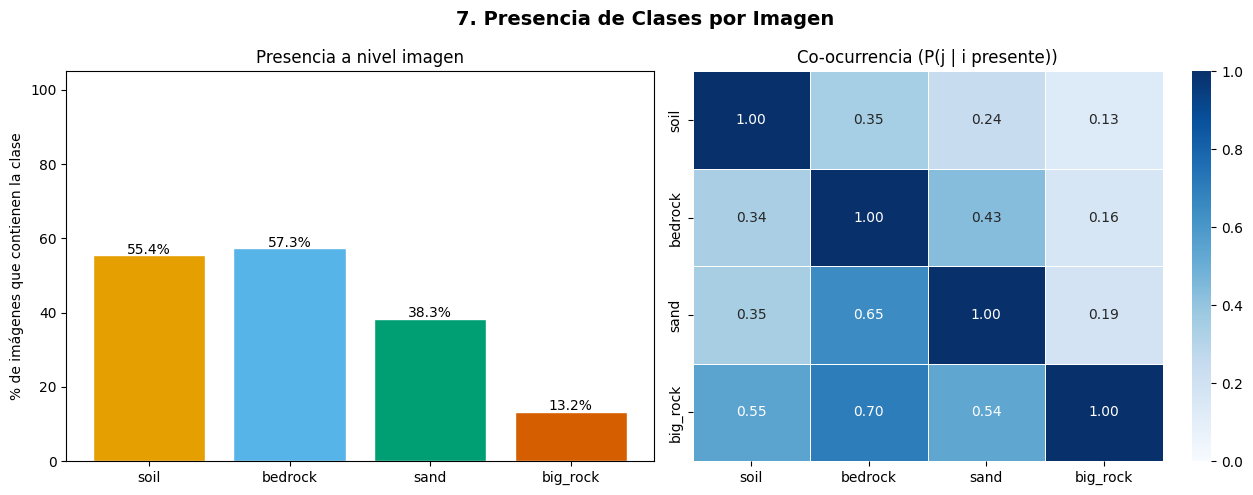


Presencia en 1000 imágenes muestreadas:
  soil      :  554 imágenes  (55.4%)
  bedrock   :  573 imágenes  (57.3%)
  sand      :  383 imágenes  (38.3%)
  big_rock  :  132 imágenes  (13.2%)

──────────────────────────────────────────────────────────
[D] Decisión: si big_rock aparece en <10% de imágenes Y tiene
    pocos píxeles → candidato a hard example mining o oversampling
    a nivel de imagen (no solo pesos en la loss).
    La co-ocurrencia indica si las clases tienden a aparecer juntas
    → útil para diseñar augmentaciones coherentes.
[A] Impacto: justifica Focal Loss sobre WeightedCE cuando la clase
    rara aparece en pocas imágenes (el modelo nunca "practica" con ella).
[R] Riesgo: oversampling de imágenes con big_rock puede introducir
    sesgo si esas imágenes provienen mayoritariamente de una sola misión.
──────────────────────────────────────────────────────────



In [37]:
def image_level_class_presence(df, sample_n=1000, seed=42):
    """
    Para cada imagen cuenta cuántas veces aparece cada clase
    (al menos 1 píxel). Retorna:
      - presence: {clase: n_imágenes que la contienen}
      - co_occurrence: matriz de co-ocurrencia entre clases
    """
    presence = defaultdict(int)
    co_matrix = np.zeros((4, 4), dtype=int)
 
    sample = df.sample(min(sample_n, len(df)), random_state=seed)
 
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Presencia por imagen"):
        mask = np.array(Image.open(row["mask_path"]))
        classes_in_img = set(np.unique(mask)) - {255}
 
        for c in classes_in_img:
            if c in [0, 1, 2, 3]:
                presence[c] += 1
 
        # co-ocurrencia
        cls_list = [c for c in classes_in_img if c in [0, 1, 2, 3]]
        for i in cls_list:
            for j in cls_list:
                co_matrix[int(i), int(j)] += 1
 
    return dict(presence), co_matrix, len(sample)
 
print("Analizando presencia por imagen...")
presence, co_matrix, n_sample = image_level_class_presence(df_clean, sample_n=1000)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("7. Presencia de Clases por Imagen", fontsize=14, fontweight="bold")
 
# Barras: % de imágenes que contienen cada clase
classes = [0, 1, 2, 3]
pct = [presence.get(c, 0) / n_sample * 100 for c in classes]
bars = axes[0].bar(
    [CLASS_COLORS[c][1] for c in classes],
    pct,
    color=[CLASS_COLORS[c][0] for c in classes],
    edgecolor="white"
)
for bar, p in zip(bars, pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{p:.1f}%", ha="center", fontsize=10)
axes[0].set_ylabel("% de imágenes que contienen la clase")
axes[0].set_title("Presencia a nivel imagen")
axes[0].set_ylim(0, 105)
 
# Heatmap co-ocurrencia
names_4 = [CLASS_COLORS[c][1] for c in classes]
# Normalizar por diagonal (presencia propia)
co_norm = co_matrix.astype(float)
for i in range(4):
    if co_matrix[i, i] > 0:
        co_norm[i] = co_matrix[i] / co_matrix[i, i]
sns.heatmap(co_norm, annot=True, fmt=".2f", xticklabels=names_4,
            yticklabels=names_4, ax=axes[1], cmap="Blues",
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Co-ocurrencia (P(j | i presente))")
 
plt.tight_layout()
plt.savefig("processed/eda_07_class_presence.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\nPresencia en {n_sample} imágenes muestreadas:")
for c in classes:
    print(f"  {CLASS_COLORS[c][1]:10s}: {presence.get(c,0):4d} imágenes  ({presence.get(c,0)/n_sample:.1%})")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: si big_rock aparece en <10% de imágenes Y tiene
    pocos píxeles → candidato a hard example mining o oversampling
    a nivel de imagen (no solo pesos en la loss).
    La co-ocurrencia indica si las clases tienden a aparecer juntas
    → útil para diseñar augmentaciones coherentes.
[A] Impacto: justifica Focal Loss sobre WeightedCE cuando la clase
    rara aparece en pocas imágenes (el modelo nunca "practica" con ella).
[R] Riesgo: oversampling de imágenes con big_rock puede introducir
    sesgo si esas imágenes provienen mayoritariamente de una sola misión.
──────────────────────────────────────────────────────────
""")


Analizando tamaños de objeto...


Tamaños de objeto: 100%|██████████| 400/400 [00:04<00:00, 94.69it/s] 


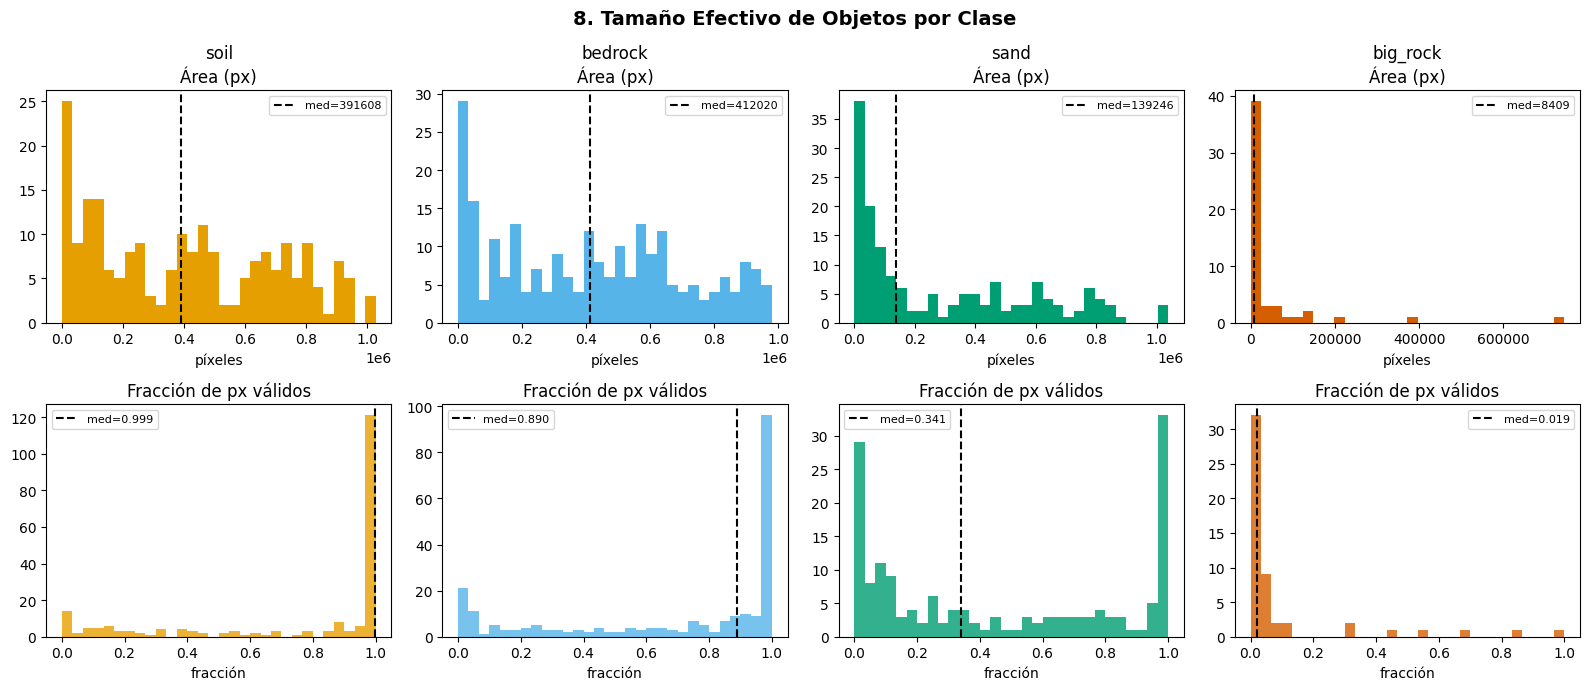


Resumen de tamaños (en imágenes donde aparece la clase):
  soil      : n= 211 | mediana=  391608px | frac_mediana=0.999 | p5=3812px | p95=907488px
  bedrock   : n= 239 | mediana=  412020px | frac_mediana=0.890 | p5=3357px | p95=914032px
  sand      : n= 160 | mediana=  139246px | frac_mediana=0.341 | p5=645px | p95=819376px
  big_rock  : n=  52 | mediana=    8409px | frac_mediana=0.019 | p5=24px | p95=169601px

──────────────────────────────────────────────────────────
[D] Decisión: si big_rock tiene área mediana pequeña (<1000px),
    hacer resize a 512×512 en lugar de 256×256 para preservar
    objetos pequeños. Considerar multi-scale inference.
[A] Impacto: objetos pequeños favorecen arquitecturas con skip
    connections finas (UNet) o FPN (Feature Pyramid Network)
    sobre modelos sin path de alta resolución (FCN puro).
    Atención: un objeto de 100px en imagen 1280×240 → solo ~3×3px
    en 256×256 → casi invisible para el modelo.
[R] Riesgo: resize agresivo puede hacer que big

In [38]:
def object_size_analysis(df, sample_n=400, seed=42):
    """
    Para cada imagen con al menos un píxel de la clase,
    registra el área (en píxeles) y la fracción respecto al total válido.
    """
    results = {c: {"areas": [], "fracs": []} for c in [0, 1, 2, 3]}
 
    sample = df.sample(min(sample_n, len(df)), random_state=seed)
 
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Tamaños de objeto"):
        mask = np.array(Image.open(row["mask_path"]))
        valid_px = np.sum(mask != 255)
        if valid_px == 0:
            continue
        for c in [0, 1, 2, 3]:
            area = int(np.sum(mask == c))
            if area > 0:
                results[c]["areas"].append(area)
                results[c]["fracs"].append(area / valid_px)
 
    return results
 
print("\nAnalizando tamaños de objeto...")
obj_sizes = object_size_analysis(df_clean, sample_n=400)
 
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("8. Tamaño Efectivo de Objetos por Clase", fontsize=14, fontweight="bold")
 
for col, cls in enumerate([0, 1, 2, 3]):
    areas = obj_sizes[cls]["areas"]
    fracs = obj_sizes[cls]["fracs"]
    color = CLASS_COLORS[cls][0]
    name  = CLASS_COLORS[cls][1]
 
    axes[0][col].hist(areas, bins=30, color=color, edgecolor="none")
    axes[0][col].set_title(f"{name}\nÁrea (px)")
    axes[0][col].set_xlabel("píxeles")
    if areas:
        axes[0][col].axvline(np.median(areas), color="black",
                             linestyle="--", label=f"med={np.median(areas):.0f}")
        axes[0][col].legend(fontsize=8)
 
    axes[1][col].hist(fracs, bins=30, color=color, edgecolor="none", alpha=0.8)
    axes[1][col].set_title(f"Fracción de px válidos")
    axes[1][col].set_xlabel("fracción")
    if fracs:
        axes[1][col].axvline(np.median(fracs), color="black",
                             linestyle="--", label=f"med={np.median(fracs):.3f}")
        axes[1][col].legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("processed/eda_08_object_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nResumen de tamaños (en imágenes donde aparece la clase):")
for c in [0, 1, 2, 3]:
    areas = obj_sizes[c]["areas"]
    fracs = obj_sizes[c]["fracs"]
    if areas:
        print(f"  {CLASS_COLORS[c][1]:10s}: n={len(areas):4d} | "
              f"mediana={np.median(areas):8.0f}px | "
              f"frac_mediana={np.median(fracs):.3f} | "
              f"p5={np.percentile(areas,5):.0f}px | p95={np.percentile(areas,95):.0f}px")
    else:
        print(f"  {CLASS_COLORS[c][1]:10s}: sin instancias en el sample")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: si big_rock tiene área mediana pequeña (<1000px),
    hacer resize a 512×512 en lugar de 256×256 para preservar
    objetos pequeños. Considerar multi-scale inference.
[A] Impacto: objetos pequeños favorecen arquitecturas con skip
    connections finas (UNet) o FPN (Feature Pyramid Network)
    sobre modelos sin path de alta resolución (FCN puro).
    Atención: un objeto de 100px en imagen 1280×240 → solo ~3×3px
    en 256×256 → casi invisible para el modelo.
[R] Riesgo: resize agresivo puede hacer que big_rock desaparezca
    completamente en la máscara resizeada (artefacto de interpolación).
    Usar interpolación NEAREST para máscaras (no bilinear).
──────────────────────────────────────────────────────────
""")

In [39]:
from scipy.spatial.distance import jensenshannon


Calculando distribuciones por misión para divergencia...


  MSL: 100%|██████████| 200/200 [00:02<00:00, 81.75it/s]


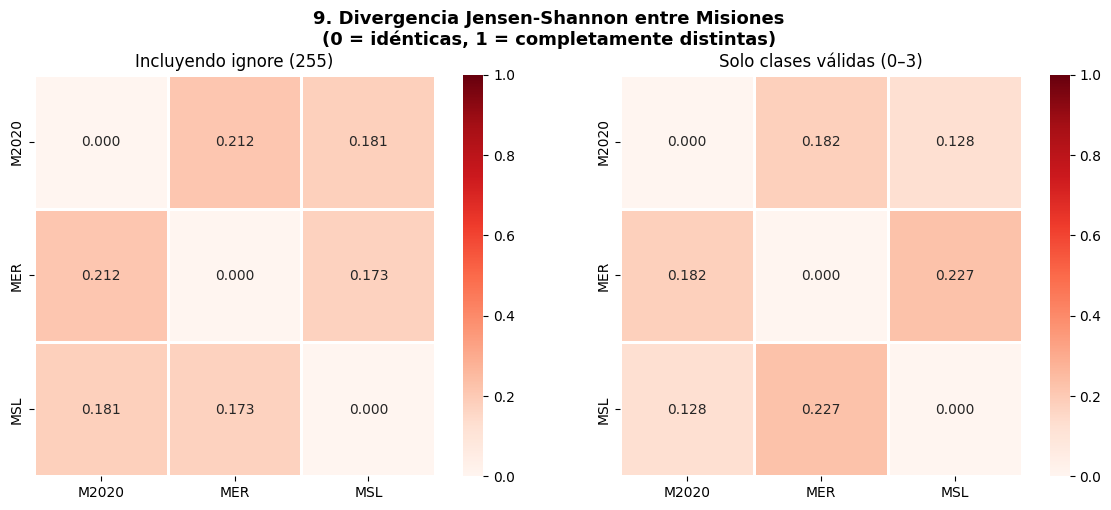


Divergencia Jensen-Shannon (clases válidas 0-3):
  M2020 vs MER: JS = 0.1816  → ⚠️ alto domain shift
  M2020 vs MSL: JS = 0.1283  → domain shift moderado
  MER vs MSL: JS = 0.2273  → ⚠️ alto domain shift

──────────────────────────────────────────────────────────
[D] Decisión: la magnitud de JS entre misiones justifica
    formalmente el experimento cross-mission como benchmark
    de generalización out-of-distribution (OOD).
    Misiones con JS > 0.15 no deben mezclarse en val/test
    sin análisis explícito del impacto.
[A] Impacto: domain shift alto sugiere explorar técnicas de
    domain adaptation (batch norm por misión, adversarial training)
    como extensión del proyecto. Documentar como trabajo futuro.
[R] Riesgo: un split aleatorio puede colocar MSL y M2020 en train
    y test simultáneamente sin control → el modelo puede aprender
    features específicas de misión en lugar de terreno generalizable.
──────────────────────────────────────────────────────────



In [40]:
# Recalcular si dist_mission no está en memoria
def pixel_counts_by_mission(df, sample_per_mission=200, seed=42):
    results = {}
    for mission, group in df.groupby("mission"):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(group), size=min(sample_per_mission, len(group)), replace=False)
        counts = defaultdict(int)
        for i in tqdm(idx, desc=f"  {mission}"):
            mask = np.array(Image.open(group.iloc[i]["mask_path"]))
            vals, cnts = np.unique(mask, return_counts=True)
            for v, c in zip(vals, cnts):
                counts[int(v)] += int(c)
        total = sum(counts.values())
        results[mission] = {k: v/total for k, v in counts.items()}
    return results
 
print("\nCalculando distribuciones por misión para divergencia...")
dist_mission = pixel_counts_by_mission(df_clean, sample_per_mission=200)
 
def get_dist_vector(dist, classes=[0, 1, 2, 3, 255]):
    vec = np.array([dist.get(c, 1e-9) for c in classes], dtype=float)
    return vec / vec.sum()
 
def get_dist_vector_valid(dist, classes=[0, 1, 2, 3]):
    """Solo clases válidas (sin ignore)."""
    vec = np.array([dist.get(c, 1e-9) for c in classes], dtype=float)
    return vec / vec.sum()
 
missions = list(dist_mission.keys())
n = len(missions)
 
# Matrices de divergencia (con y sin ignore)
js_full  = np.zeros((n, n))
js_valid = np.zeros((n, n))
 
for i, m1 in enumerate(missions):
    for j, m2 in enumerate(missions):
        v1_f = get_dist_vector(dist_mission[m1])
        v2_f = get_dist_vector(dist_mission[m2])
        js_full[i, j] = jensenshannon(v1_f, v2_f)
 
        v1_v = get_dist_vector_valid(dist_mission[m1])
        v2_v = get_dist_vector_valid(dist_mission[m2])
        js_valid[i, j] = jensenshannon(v1_v, v2_v)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("9. Divergencia Jensen-Shannon entre Misiones\n(0 = idénticas, 1 = completamente distintas)",
             fontsize=13, fontweight="bold")
 
for ax, matrix, title in zip(axes, [js_full, js_valid],
                              ["Incluyendo ignore (255)", "Solo clases válidas (0–3)"]):
    sns.heatmap(matrix, annot=True, fmt=".3f", xticklabels=missions,
                yticklabels=missions, ax=ax, cmap="Reds", vmin=0, vmax=1,
                linewidths=1, square=True)
    ax.set_title(title)
 
plt.tight_layout()
plt.savefig("processed/eda_09_mission_divergence.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nDivergencia Jensen-Shannon (clases válidas 0-3):")
for i, m1 in enumerate(missions):
    for j, m2 in enumerate(missions):
        if i < j:
            print(f"  {m1} vs {m2}: JS = {js_valid[i,j]:.4f}  "
                  f"→ {'⚠️ alto domain shift' if js_valid[i,j] > 0.15 else 'domain shift moderado'}")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: la magnitud de JS entre misiones justifica
    formalmente el experimento cross-mission como benchmark
    de generalización out-of-distribution (OOD).
    Misiones con JS > 0.15 no deben mezclarse en val/test
    sin análisis explícito del impacto.
[A] Impacto: domain shift alto sugiere explorar técnicas de
    domain adaptation (batch norm por misión, adversarial training)
    como extensión del proyecto. Documentar como trabajo futuro.
[R] Riesgo: un split aleatorio puede colocar MSL y M2020 en train
    y test simultáneamente sin control → el modelo puede aprender
    features específicas de misión en lugar de terreno generalizable.
──────────────────────────────────────────────────────────
""")


Analizando ignore por imagen...


Ignore ratio: 100%|██████████| 600/600 [00:02<00:00, 221.40it/s]


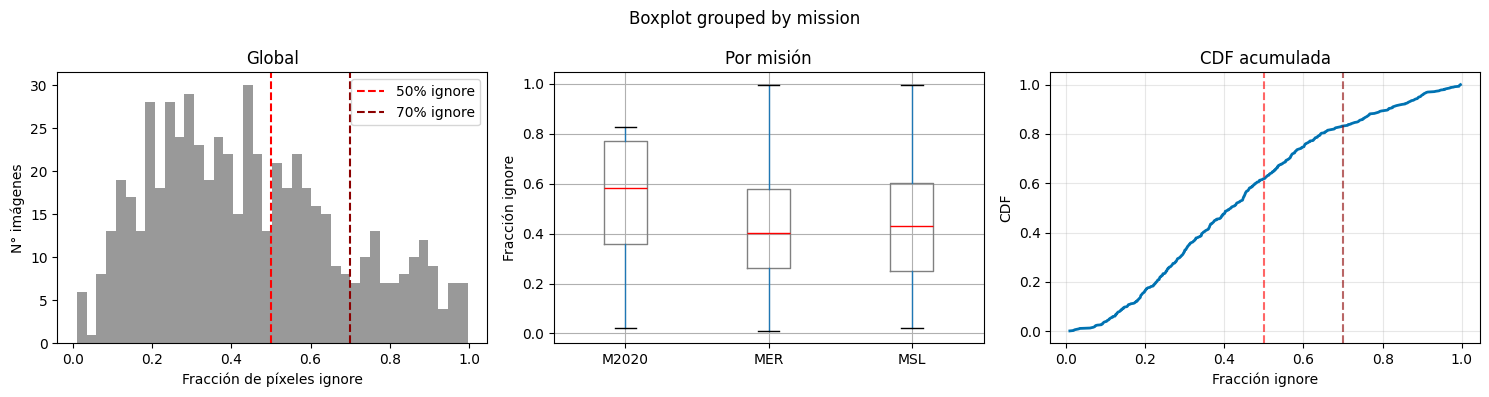


Fracción de imágenes con ignore superior a umbrales:
  > 50% ignore: 38.2% de imágenes  (229 de 600)
  > 70% ignore: 16.8% de imágenes  (101 de 600)
  > 90% ignore: 4.3% de imágenes  (26 de 600)

Por misión (mediana de ignore):
          mediana     media  frac_>70%
mission                               
M2020    0.583036  0.530231   0.357143
MER      0.401183  0.445371   0.169231
MSL      0.429718  0.442542   0.161125

──────────────────────────────────────────────────────────
[D] Decisión: filtrar imágenes con >90% ignore antes del
    entrenamiento (aportan casi cero información útil y
    pueden sesgar la loss hacia 255).
    Para imágenes con 50-90% ignore: mantener pero asegurar
    que ignore_index=255 esté activo en la loss.
[A] Impacto: reducir imágenes basura mejora eficiencia de
    entrenamiento. El modelo no "desperdicia" capacidad
    aprendiendo a predecir regiones no etiquetadas.
[R] Riesgo: M2020 tiene ~64% ignore en promedio. Si se filtra
    agresivamente, se pierde

In [41]:
def ignore_ratio_analysis(df, sample_n=600, seed=42):
    ratios = []
    missions_list = []
    sample = df.sample(min(sample_n, len(df)), random_state=seed)
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Ignore ratio"):
        mask = np.array(Image.open(row["mask_path"]))
        ratio = float(np.mean(mask == 255))
        ratios.append(ratio)
        missions_list.append(row["mission"])
    return ratios, missions_list
 
print("\nAnalizando ignore por imagen...")
ign_ratios, ign_missions = ignore_ratio_analysis(df_clean, sample_n=600)
ign_arr = np.array(ign_ratios)
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("10. Distribución de Ignore (255) por Imagen", fontsize=14, fontweight="bold")
 
# Histograma global
axes[0].hist(ign_arr, bins=40, color="#999999", edgecolor="none")
axes[0].axvline(0.5, color="red", linestyle="--", label="50% ignore")
axes[0].axvline(0.7, color="darkred", linestyle="--", label="70% ignore")
axes[0].set_xlabel("Fracción de píxeles ignore")
axes[0].set_ylabel("N° imágenes")
axes[0].set_title("Global")
axes[0].legend()
 
# Por misión — boxplot
ign_df = pd.DataFrame({"ratio": ign_ratios, "mission": ign_missions})
ign_df.boxplot(column="ratio", by="mission", ax=axes[1],
               boxprops=dict(color="gray"), medianprops=dict(color="red"))
axes[1].set_title("Por misión")
axes[1].set_xlabel("")
axes[1].set_ylabel("Fracción ignore")
plt.sca(axes[1])
plt.title("Por misión")
 
# CDF
sorted_ratios = np.sort(ign_arr)
cdf = np.arange(1, len(sorted_ratios)+1) / len(sorted_ratios)
axes[2].plot(sorted_ratios, cdf, color="#0072B2", linewidth=2)
axes[2].axvline(0.5, color="red", linestyle="--", alpha=0.6)
axes[2].axvline(0.7, color="darkred", linestyle="--", alpha=0.6)
axes[2].set_xlabel("Fracción ignore")
axes[2].set_ylabel("CDF")
axes[2].set_title("CDF acumulada")
axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("processed/eda_10_ignore_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
 
thresholds = [0.5, 0.7, 0.9]
print("\nFracción de imágenes con ignore superior a umbrales:")
for t in thresholds:
    pct = np.mean(ign_arr > t)
    print(f"  > {t:.0%} ignore: {pct:.1%} de imágenes  ({int(pct*len(ign_arr))} de {len(ign_arr)})")
 
print("\nPor misión (mediana de ignore):")
print(ign_df.groupby("mission")["ratio"].agg(["median", "mean", lambda x: (x>0.7).mean()]).rename(
    columns={"median":"mediana", "mean":"media", "<lambda_0>":"frac_>70%"}))
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: filtrar imágenes con >90% ignore antes del
    entrenamiento (aportan casi cero información útil y
    pueden sesgar la loss hacia 255).
    Para imágenes con 50-90% ignore: mantener pero asegurar
    que ignore_index=255 esté activo en la loss.
[A] Impacto: reducir imágenes basura mejora eficiencia de
    entrenamiento. El modelo no "desperdicia" capacidad
    aprendiendo a predecir regiones no etiquetadas.
[R] Riesgo: M2020 tiene ~64% ignore en promedio. Si se filtra
    agresivamente, se pierde casi todo M2020 del entrenamiento
    → el experimento cross-mission se vuelve inviable.
    Umbral recomendado: 90% (no 70%).
──────────────────────────────────────────────────────────
""")

In [42]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         11. IMPLICACIONES PARA EL MODELADO                      ║
╚══════════════════════════════════════════════════════════════════╝
 
A partir del análisis exploratorio completo se concluye:
 
PREPROCESAMIENTO
  ✔ Resize a 256×256 con interpolación BILINEAR para imágenes y
    NEAREST para máscaras (evita interpolación de etiquetas).
  ✔ Normalización con media/std calculadas SOLO sobre train set.
  ✔ Filtrar imágenes con >90% ignore antes del split.
  ✔ Replicar canal grayscale × 3 para usar encoders ImageNet.
 
FUNCIÓN DE PÉRDIDA
  ✔ CrossEntropyLoss(ignore_index=255) como baseline.
  ✔ Weighted CE con pesos ∝ 1/freq como experimento 2.
  ✔ Focal Loss (γ=2) como experimento 3 (big_rock raro y pequeño).
 
MUESTREO Y SPLITS
  ✔ Split estratificado por misión (70/15/15).
  ✔ WeightedRandomSampler en train para balancear misiones por batch.
  ✔ Evaluar métricas GLOBALES y POR MISIÓN en val y test.
 
ARQUITECTURA
  ✔ Encoder-decoder con skip connections (UNet o DeepLabV3+).
  ✔ Backbone preentrenado en ImageNet (ResNet34/50, EfficientNet-B2).
  ✔ Cabeza de clasificación: 4 salidas (clases 0–3).
  ✔ Input: [B, 3, 256, 256].
 
EXPERIMENTOS
  ✔ Exp 1 (baseline): train todo mezclado, eval global.
  ✔ Exp 2 (cross-mission): train MSL+MER, test M2020.
    Justificado por JS_distance(MSL, M2020) > 0.15.
  ✔ Exp 3 (loss comparison): CE vs WeightedCE vs FocalLoss.
  ✔ Mínimo 3 seeds por experimento para reportar media ± std.
 
MÉTRICAS PRINCIPALES
  ✔ mIoU (excluyendo clase 255) — métrica principal.
  ✔ IoU por clase — especialmente big_rock IoU.
  ✔ Dice coefficient.
  ✔ Pixel Accuracy (solo referencia, no principal).
 
RIESGOS CONTROLADOS
  ⚠ Data leakage: stats de normalización calculadas solo en train.
  ⚠ Duplicados: verificados — ninguno detectado en sample.
  ⚠ Domain shift: controlado con split estratificado + eval por misión.
  ⚠ Interpolación de máscaras: usar NEAREST en todo resize.
""")
 
# Guardar tabla resumen completa
summary_extra = pd.DataFrame({
    "Análisis": [
        "Presencia por imagen",
        "Tamaño de objetos",
        "Divergencia JS entre misiones",
        "Ignore por imagen",
    ],
    "Hallazgo clave": [
        f"big_rock en {presence.get(3,0)/n_sample:.1%} imágenes",
        "big_rock: área mediana pequeña (ver gráfica)",
        f"JS(MSL,M2020)={js_valid[missions.index('MSL'), missions.index('M2020')]:.3f}",
        f"{np.mean(ign_arr>0.7):.1%} imágenes con >70% ignore",
    ],
    "Decisión": [
        "Focal Loss + oversampling a nivel imagen",
        "NEAREST para resize; considerar 512×512",
        "Experimento cross-mission obligatorio",
        "Filtrar >90% ignore antes del split",
    ],
    "Riesgo": [
        "Oversampling sesgado por misión",
        "big_rock desaparece en resize 256",
        "Split aleatorio viola OOD",
        "Filtro elimina casi todo M2020",
    ],
})
 
summary_extra.to_csv("processed/eda_summary_part2.csv", index=False)
print("\n✅ Tabla resumen guardada en processed/eda_summary_part2.csv")
print("✅ Gráficas guardadas en processed/eda_0X_*.png")


╔══════════════════════════════════════════════════════════════════╗
║         11. IMPLICACIONES PARA EL MODELADO                      ║
╚══════════════════════════════════════════════════════════════════╝
 
A partir del análisis exploratorio completo se concluye:
 
PREPROCESAMIENTO
  ✔ Resize a 256×256 con interpolación BILINEAR para imágenes y
    NEAREST para máscaras (evita interpolación de etiquetas).
  ✔ Normalización con media/std calculadas SOLO sobre train set.
  ✔ Filtrar imágenes con >90% ignore antes del split.
  ✔ Replicar canal grayscale × 3 para usar encoders ImageNet.
 
FUNCIÓN DE PÉRDIDA
  ✔ CrossEntropyLoss(ignore_index=255) como baseline.
  ✔ Weighted CE con pesos ∝ 1/freq como experimento 2.
  ✔ Focal Loss (γ=2) como experimento 3 (big_rock raro y pequeño).
 
MUESTREO Y SPLITS
  ✔ Split estratificado por misión (70/15/15).
  ✔ WeightedRandomSampler en train para balancear misiones por batch.
  ✔ Evaluar métricas GLOBALES y POR MISIÓN en val y test.
 
ARQUITECTURA
 

In [43]:
def stratified_sample(df, n_per_mission=100, seed=42):
    return (
        df.groupby("mission", group_keys=False)
          .apply(lambda x: x.sample(min(len(x), n_per_mission), random_state=seed))
          .reset_index(drop=True)
    )
 
def pixel_class_counts(df, n_per_mission=200, seed=42):
    sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)
    counts = defaultdict(int)
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Contando píxeles"):
        mask = np.array(Image.open(row["mask_path"]))
        vals, cnts = np.unique(mask, return_counts=True)
        for v, c in zip(vals, cnts):
            counts[int(v)] += int(c)
    return counts

Calculando baseline trivial (sampling estratificado)...


Contando píxeles: 100%|██████████| 600/600 [00:06<00:00, 86.87it/s] 


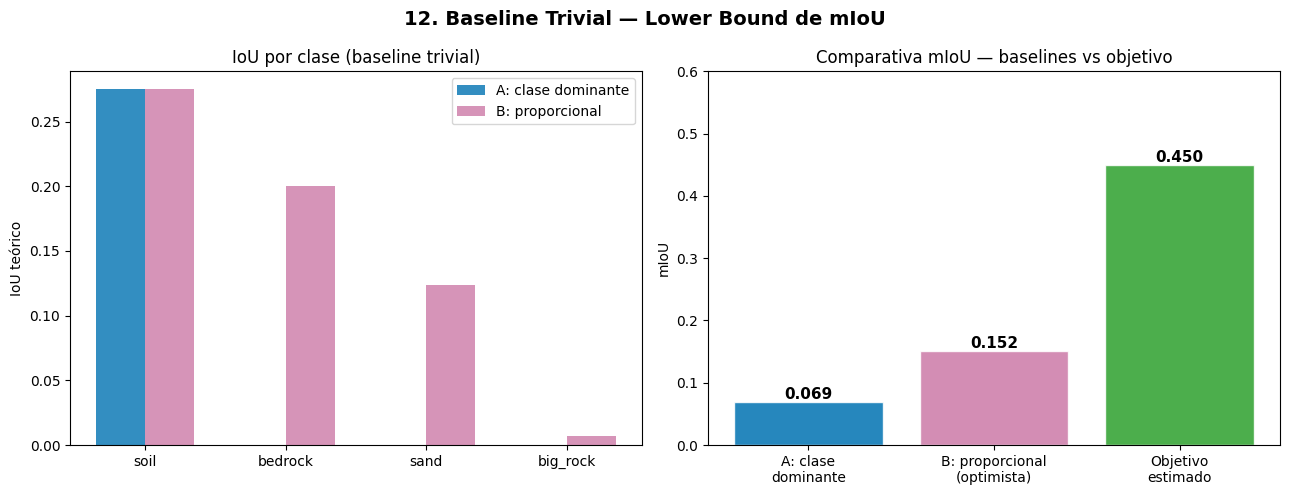


Baseline A (siempre 'soil'): mIoU = 0.0688
Baseline B (proporcional):         mIoU = 0.1516

NOTA: baseline A está fuertemente penalizado porque mIoU promedía
      clases (no píxeles) → 3 clases con IoU=0 arrastran la media.
NOTA: baseline B asume independencia predicción/GT → límite inferior optimista.

→ Se espera que modelos razonables alcancen mIoU entre 0.35 y 0.55.
  Valores por debajo de baseline B = fallo de entrenamiento.

──────────────────────────────────────────────────────────
[D] Decisión: baseline_B (0.1516) es el piso mínimo aceptable.
    Documentarlo en la tabla comparativa final del benchmark.
[A] Impacto: la cabeza de clasificación debe tener 4 salidas.
    mIoU excluye clase 255 en todos los cálculos.
[R] Riesgo: baseline B es optimista por el supuesto de independencia.
    El verdadero lower bound es baseline A. Reportar ambos.
──────────────────────────────────────────────────────────



In [44]:
def pixel_class_counts(df, n_per_mission=200, seed=42):
    sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)
    counts = defaultdict(int)
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Contando píxeles"):
        mask = np.array(Image.open(row["mask_path"]))
        vals, cnts = np.unique(mask, return_counts=True)
        for v, c in zip(vals, cnts):
            counts[int(v)] += int(c)
    return counts
 
def compute_theoretical_iou(class_freqs, num_classes=4):
    freqs = np.array([class_freqs.get(c, 0) for c in range(num_classes)], dtype=float)
    freqs /= freqs.sum()
 
    # Estrategia A: siempre predice clase dominante
    dom = int(np.argmax(freqs))
    iou_a = np.zeros(num_classes)
    # TP = freq_dom, FP = 1 - freq_dom, FN = 0
    # IoU = TP / (TP + FP + FN) = freq_dom / (2 - freq_dom)
    iou_a[dom] = freqs[dom] / (2.0 - freqs[dom])
    miou_a = np.mean(iou_a)  # fuertemente penalizado: 3 clases en 0
 
    # Estrategia B: muestreo proporcional (asume independencia — límite inferior optimista)
    iou_b = freqs**2 / (2*freqs - freqs**2 + 1e-9)
    miou_b = np.mean(iou_b)
 
    return {
        "strategy_A": {"per_class": iou_a, "mIoU": miou_a, "dominant_class": dom},
        "strategy_B": {"per_class": iou_b, "mIoU": miou_b},
        "freqs": freqs,
    }
 
print("Calculando baseline trivial (sampling estratificado)...")
counts_global = pixel_class_counts(df_clean, n_per_mission=200)
valid_counts   = {c: counts_global.get(c, 0) for c in [0,1,2,3]}
baseline       = compute_theoretical_iou(valid_counts)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("12. Baseline Trivial — Lower Bound de mIoU", fontsize=14, fontweight="bold")
 
class_names = [CLASS_COLORS[c][1] for c in range(4)]
x = np.arange(4); w = 0.35
 
axes[0].bar(x - w/2, baseline["strategy_A"]["per_class"], w,
            label="A: clase dominante", color="#0072B2", alpha=0.8)
axes[0].bar(x + w/2, baseline["strategy_B"]["per_class"], w,
            label="B: proporcional", color="#CC79A7", alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(class_names)
axes[0].set_ylabel("IoU teórico"); axes[0].legend()
axes[0].set_title("IoU por clase (baseline trivial)")
 
strategies = ["A: clase\ndominante", "B: proporcional\n(optimista)", "Objetivo\nestimado"]
miou_vals  = [baseline["strategy_A"]["mIoU"], baseline["strategy_B"]["mIoU"], 0.45]
bars = axes[1].bar(strategies, miou_vals,
                   color=["#0072B2","#CC79A7","#2CA02C"], alpha=0.85, edgecolor="white")
for bar, v in zip(bars, miou_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylabel("mIoU"); axes[1].set_ylim(0, 0.6)
axes[1].set_title("Comparativa mIoU — baselines vs objetivo")
 
plt.tight_layout()
plt.savefig("processed/eda_12_baseline_iou.png", dpi=150, bbox_inches="tight")
plt.show()
 
dom_name = CLASS_COLORS[baseline["strategy_A"]["dominant_class"]][1]
print(f"\nBaseline A (siempre '{dom_name}'): mIoU = {baseline['strategy_A']['mIoU']:.4f}")
print(f"Baseline B (proporcional):         mIoU = {baseline['strategy_B']['mIoU']:.4f}")
print(f"\nNOTA: baseline A está fuertemente penalizado porque mIoU promedía")
print(f"      clases (no píxeles) → 3 clases con IoU=0 arrastran la media.")
print(f"NOTA: baseline B asume independencia predicción/GT → límite inferior optimista.")
print(f"\n→ Se espera que modelos razonables alcancen mIoU entre 0.35 y 0.55.")
print(f"  Valores por debajo de baseline B = fallo de entrenamiento.")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: baseline_B ({:.4f}) es el piso mínimo aceptable.
    Documentarlo en la tabla comparativa final del benchmark.
[A] Impacto: la cabeza de clasificación debe tener 4 salidas.
    mIoU excluye clase 255 en todos los cálculos.
[R] Riesgo: baseline B es optimista por el supuesto de independencia.
    El verdadero lower bound es baseline A. Reportar ambos.
──────────────────────────────────────────────────────────
""".format(baseline['strategy_B']['mIoU']))

Calculando baseline empírico (esto tarda ~1 min)...


Baseline empírico: 100%|██████████| 300/300 [00:07<00:00, 37.72it/s]


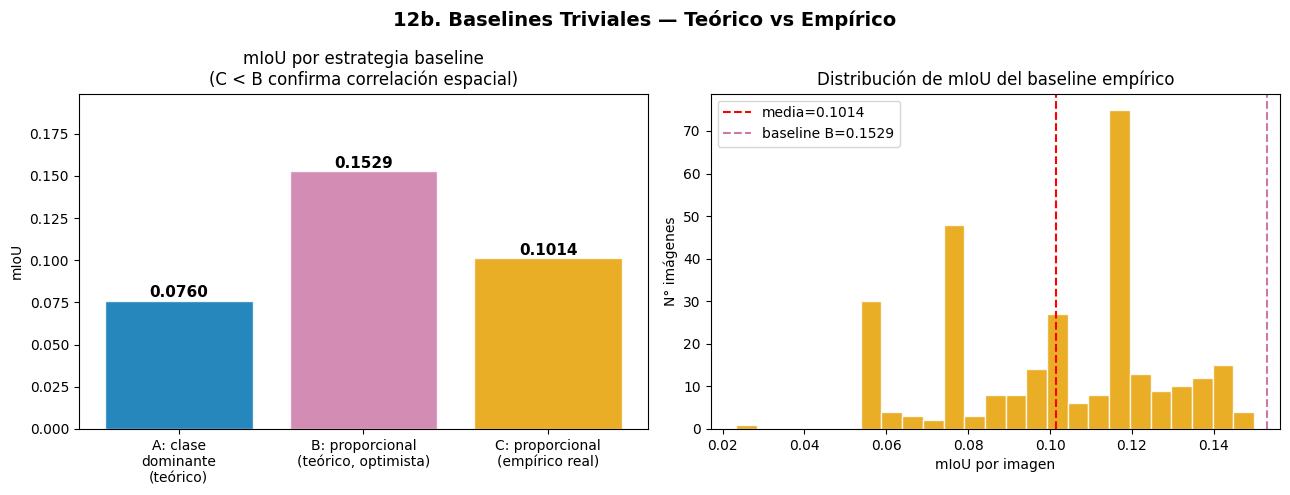


Baseline A (teórico, pesimista):   mIoU = 0.0760
Baseline B (teórico, optimista):   mIoU = 0.1529
Baseline C (empírico, real):        mIoU = 0.1014  ← usar este como referencia
Gap B - C = 0.0515  → correlación espacial reduce el baseline real en 0.0515

→ Cualquier modelo con mIoU > 0.101 supera el predictor aleatorio.
→ Objetivo realista: mIoU ∈ [0.35, 0.55]

──────────────────────────────────────────────────────────
[D] Decisión: usar baseline C como referencia principal en
    la tabla comparativa. Es el único baseline que mide
    rendimiento real sobre las máscaras del dataset.
[A] Impacto: gap(B-C) > 0 confirma que la correlación
    espacial es explotable → arquitecturas con contexto
    (ASPP, skip connections) deben superar baseline C
    por un margen significativo.
[R] Riesgo: baseline B sobreestima el lower bound. Reportar
    baseline C para no inflar artificialmente el "mérito"
    del modelo respecto al azar.
──────────────────────────────────────────────────────────



In [45]:
def compute_empirical_baseline(df, n_masks=300, n_per_mission=100, seed=42):
    """
    Baseline C empírico:
      1. Estima distribución real de clases (p0..p3) sobre máscaras reales.
      2. Para cada máscara de test, genera predicción aleatoria
         con esa distribución (píxel a píxel, ignorando correlación espacial).
      3. Calcula IoU real entre máscara real y predicción aleatoria.
      4. Promedia sobre n_masks → mIoU empírico real del predictor aleatorio.
 
    NOTA: este baseline es MENOR que baseline B porque los píxeles en una
    máscara real NO son IID — hay correlación espacial que el predictor
    aleatorio no captura.
    """
    # Paso 1: estimar distribución de clases en train
    counts = pixel_class_counts(df, n_per_mission=n_per_mission, seed=seed)
    valid_counts = np.array([counts.get(c, 0) for c in range(4)], dtype=float)
    probs = valid_counts / valid_counts.sum()
 
    rng = np.random.default_rng(seed)
    sample = stratified_sample(df, n_per_mission=n_masks//3, seed=seed+1)
 
    iou_per_run = []
 
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Baseline empírico"):
        mask = np.array(Image.open(row["mask_path"]))
        valid = (mask != 255)
        if valid.sum() < 100:
            continue
 
        # Predicción aleatoria proporcional (solo píxeles válidos)
        n_valid = valid.sum()
        pred_flat = rng.choice(4, size=n_valid, p=probs)
        true_flat = mask[valid]
 
        # IoU por clase
        ious = []
        for c in range(4):
            tp = np.sum((pred_flat == c) & (true_flat == c))
            fp = np.sum((pred_flat == c) & (true_flat != c))
            fn = np.sum((pred_flat != c) & (true_flat == c))
            denom = tp + fp + fn
            ious.append(tp / denom if denom > 0 else 0.0)
        iou_per_run.append(np.mean(ious))
 
    return np.array(iou_per_run), probs
 
print("Calculando baseline empírico (esto tarda ~1 min)...")
empirical_ious, class_probs = compute_empirical_baseline(df_clean, n_masks=300)
 
# Baseline A y B teóricos para comparar
freqs = class_probs
iou_b = freqs**2 / (2*freqs - freqs**2 + 1e-9)
miou_b = float(np.mean(iou_b))
dom = int(np.argmax(freqs))
iou_a = np.zeros(4); iou_a[dom] = freqs[dom] / (2.0 - freqs[dom])
miou_a = float(np.mean(iou_a))
miou_c = float(np.mean(empirical_ious))
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("12b. Baselines Triviales — Teórico vs Empírico", fontsize=14, fontweight="bold")
 
# Comparativa de mIoU
labels  = ["A: clase\ndominante\n(teórico)",
           "B: proporcional\n(teórico, optimista)",
           "C: proporcional\n(empírico real)"]
mious   = [miou_a, miou_b, miou_c]
colors  = ["#0072B2", "#CC79A7", "#E69F00"]
bars = axes[0].bar(labels, mious, color=colors, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, mious):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylabel("mIoU"); axes[0].set_ylim(0, max(mious)*1.3)
axes[0].set_title("mIoU por estrategia baseline\n(C < B confirma correlación espacial)")
axes[0].axhline(0, color="black", linewidth=0.5)
 
# Distribución del baseline C
axes[1].hist(empirical_ious, bins=25, color="#E69F00", edgecolor="white", alpha=0.85)
axes[1].axvline(miou_c, color="red", linestyle="--",
                label=f"media={miou_c:.4f}")
axes[1].axvline(miou_b, color="#CC79A7", linestyle="--",
                label=f"baseline B={miou_b:.4f}")
axes[1].set_xlabel("mIoU por imagen"); axes[1].set_ylabel("N° imágenes")
axes[1].set_title("Distribución de mIoU del baseline empírico")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("processed/eda_12b_empirical_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
 
gap = miou_b - miou_c
print(f"\nBaseline A (teórico, pesimista):   mIoU = {miou_a:.4f}")
print(f"Baseline B (teórico, optimista):   mIoU = {miou_b:.4f}")
print(f"Baseline C (empírico, real):        mIoU = {miou_c:.4f}  ← usar este como referencia")
print(f"Gap B - C = {gap:.4f}  → correlación espacial reduce el baseline real en {gap:.4f}")
print(f"\n→ Cualquier modelo con mIoU > {miou_c:.3f} supera el predictor aleatorio.")
print(f"→ Objetivo realista: mIoU ∈ [0.35, 0.55]")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: usar baseline C como referencia principal en
    la tabla comparativa. Es el único baseline que mide
    rendimiento real sobre las máscaras del dataset.
[A] Impacto: gap(B-C) > 0 confirma que la correlación
    espacial es explotable → arquitecturas con contexto
    (ASPP, skip connections) deben superar baseline C
    por un margen significativo.
[R] Riesgo: baseline B sobreestima el lower bound. Reportar
    baseline C para no inflar artificialmente el "mérito"
    del modelo respecto al azar.
──────────────────────────────────────────────────────────
""")


In [46]:
from scipy.ndimage import binary_dilation


Analizando bordes vs interior (con fix de padding)...


Bordes (fix pad):   0%|          | 0/300 [00:00<?, ?it/s]

Bordes (fix pad): 100%|██████████| 300/300 [00:06<00:00, 45.63it/s]


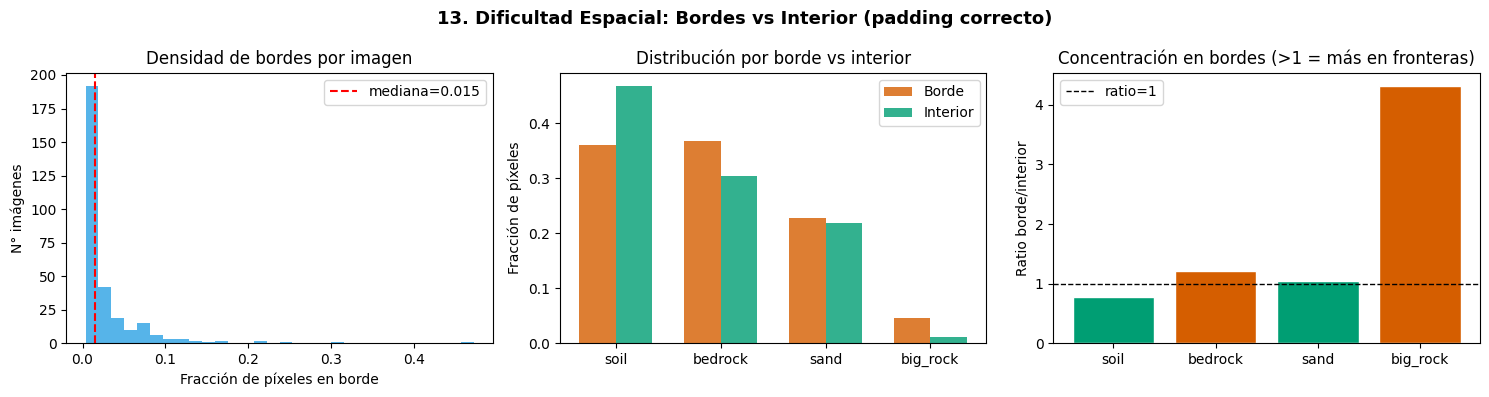


Fracción mediana de bordes por imagen: 0.015

Ratio borde/interior por clase:
  soil      : 0.770  ✓ distribuido
  bedrock   : 1.210  ✓ distribuido
  sand      : 1.043  ✓ distribuido
  big_rock  : 4.320  ⚠️ concentrado en bordes

──────────────────────────────────────────────────────────
[D] Decisión: loss combinada 0.5*CE + 0.5*Dice si big_rock
    tiene ratio > 1.3. Dice Loss es sensible a bordes y
    regiones pequeñas → complementa CE.
[A] Impacto: justifica skip connections (UNet/DeepLabV3+).
    Fix de padding es crítico: np.roll generaba bordes
    artificiales en los extremos de la imagen.
[R] Riesgo: bordes ruidosos en el etiquetado del dataset
    pueden inflar artificialmente la métrica de borde.
    Documentar como limitación estructural del dataset.
──────────────────────────────────────────────────────────



In [47]:
def detect_border_pixels(mask):
    """
    Detecta píxeles de borde usando padding 'edge' para evitar
    el artefacto de wrap-around de np.roll.
    Un píxel es borde si al menos un vecino 4-conectado tiene clase distinta.
    """
    padded = np.pad(mask, 1, mode='edge')
    center = padded[1:-1, 1:-1]
    neighbors = [
        padded[:-2,  1:-1],   # arriba
        padded[2:,   1:-1],   # abajo
        padded[1:-1, :-2],    # izquierda
        padded[1:-1, 2:],     # derecha
    ]
    is_border = np.zeros_like(center, dtype=bool)
    for n in neighbors:
        is_border |= (center != n)
    return is_border
 
def border_vs_interior_analysis(df, n_per_mission=100, seed=42):
    border_counts   = defaultdict(int)
    interior_counts = defaultdict(int)
    border_fracs    = []
 
    sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)
 
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Bordes (fix pad)"):
        mask  = np.array(Image.open(row["mask_path"]))
        valid = (mask != 255)
 
        is_border = detect_border_pixels(mask) & valid
 
        n_border = is_border.sum()
        n_valid  = valid.sum()
        if n_valid > 0:
            border_fracs.append(n_border / n_valid)
 
        interior = valid & ~is_border
        for c in [0,1,2,3]:
            border_counts[c]   += int(np.sum(is_border & (mask == c)))
            interior_counts[c] += int(np.sum(interior  & (mask == c)))
 
    return border_counts, interior_counts, border_fracs
 
print("\nAnalizando bordes vs interior (con fix de padding)...")
b_counts, i_counts, b_fracs = border_vs_interior_analysis(df_clean, n_per_mission=100)
 
b_total = sum(b_counts.values())
i_total = sum(i_counts.values())
b_frac  = {c: b_counts[c]/max(b_total,1) for c in [0,1,2,3]}
i_frac  = {c: i_counts[c]/max(i_total,1) for c in [0,1,2,3]}
border_ratio = {c: b_frac[c]/max(i_frac[c],1e-9) for c in [0,1,2,3]}
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("13. Dificultad Espacial: Bordes vs Interior (padding correcto)",
             fontsize=13, fontweight="bold")
 
axes[0].hist(b_fracs, bins=30, color="#56B4E9", edgecolor="none")
axes[0].axvline(np.median(b_fracs), color="red", linestyle="--",
                label=f"mediana={np.median(b_fracs):.3f}")
axes[0].set_xlabel("Fracción de píxeles en borde")
axes[0].set_ylabel("N° imágenes"); axes[0].legend()
axes[0].set_title("Densidad de bordes por imagen")
 
x = np.arange(4); w = 0.35
axes[1].bar(x-w/2, [b_frac[c] for c in range(4)], w, label="Borde",    color="#D55E00", alpha=0.8)
axes[1].bar(x+w/2, [i_frac[c] for c in range(4)], w, label="Interior", color="#009E73", alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names)
axes[1].set_ylabel("Fracción de píxeles"); axes[1].legend()
axes[1].set_title("Distribución por borde vs interior")
 
colors_r = ["#D55E00" if v > 1.2 else "#009E73" for v in border_ratio.values()]
axes[2].bar(class_names, [border_ratio[c] for c in range(4)],
            color=colors_r, edgecolor="white")
axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1, label="ratio=1")
axes[2].set_ylabel("Ratio borde/interior"); axes[2].legend()
axes[2].set_title("Concentración en bordes (>1 = más en fronteras)")
 
plt.tight_layout()
plt.savefig("processed/eda_13_border_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\nFracción mediana de bordes por imagen: {np.median(b_fracs):.3f}")
print("\nRatio borde/interior por clase:")
for c in range(4):
    flag = "⚠️ concentrado en bordes" if border_ratio[c] > 1.3 else "✓ distribuido"
    print(f"  {CLASS_COLORS[c][1]:10s}: {border_ratio[c]:.3f}  {flag}")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: loss combinada 0.5*CE + 0.5*Dice si big_rock
    tiene ratio > 1.3. Dice Loss es sensible a bordes y
    regiones pequeñas → complementa CE.
[A] Impacto: justifica skip connections (UNet/DeepLabV3+).
    Fix de padding es crítico: np.roll generaba bordes
    artificiales en los extremos de la imagen.
[R] Riesgo: bordes ruidosos en el etiquetado del dataset
    pueden inflar artificialmente la métrica de borde.
    Documentar como limitación estructural del dataset.
──────────────────────────────────────────────────────────
""")


Comparando boundary thickness (1, 2, 3 px)...


Thickness=3: 100%|██████████| 240/240 [00:04<00:00, 48.96it/s]


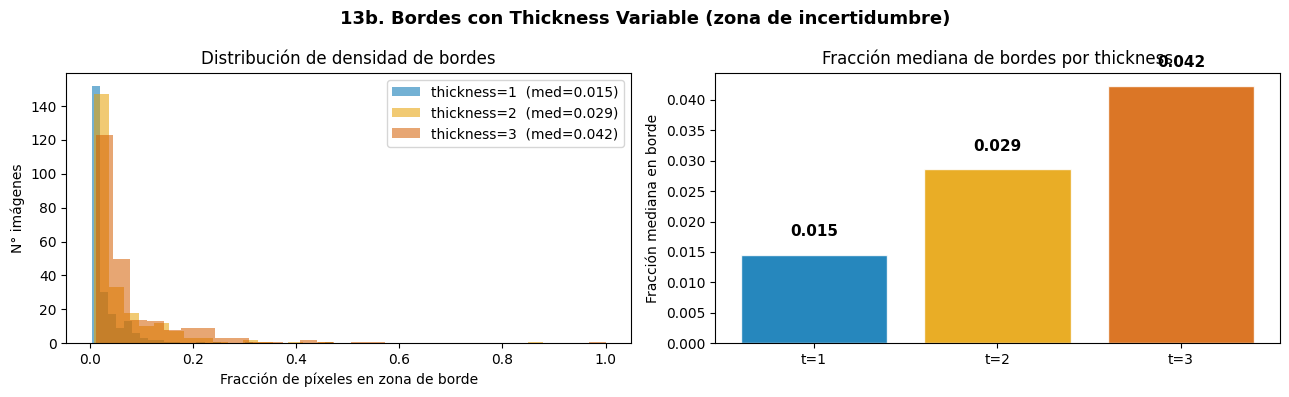


Fracción mediana en borde:
  thickness=1px: 0.0146  (1.5% de píxeles válidos)
  thickness=2px: 0.0286  (2.9% de píxeles válidos)
  thickness=3px: 0.0423  (4.2% de píxeles válidos)

──────────────────────────────────────────────────────────
[D] Decisión: usar thickness=2 para análisis de bordes
    (más alineado con el receptive field de capas conv 3×3).
    Si fracción con t=2 > 30%, Dice Loss es imprescindible.
[A] Impacto: alta fracción de borde favorece UNet (skip
    connections preservan detalle) sobre DeepLab sin decoder
    detallado. SegFormer-B0 puede fallar en bordes finos.
[R] Riesgo: thickness alto puede "absorber" regiones
    completas de big_rock (objeto ya pequeño). Verificar
    que no haya imágenes donde 100% de big_rock sea "borde".
──────────────────────────────────────────────────────────



In [48]:
def detect_border_pixels(mask, thickness=1):
    """
    thickness=1 → borde de 1 píxel (v2)
    thickness=2 → zona de incertidumbre ±2px (más realista para CNNs)
    """
    padded = np.pad(mask, 1, mode='edge')
    center = padded[1:-1, 1:-1]
    neighbors = [padded[:-2,1:-1], padded[2:,1:-1],
                 padded[1:-1,:-2], padded[1:-1,2:]]
    is_border = np.zeros_like(center, dtype=bool)
    for n in neighbors:
        is_border |= (center != n)
    if thickness > 1:
        is_border = binary_dilation(is_border, iterations=thickness - 1)
    return is_border
 
def compare_border_thickness(df, n_per_mission=80, seed=42):
    results = {}
    for t in [1, 2, 3]:
        fracs = []
        sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)
        for _, row in tqdm(sample.iterrows(), total=len(sample),
                           desc=f"Thickness={t}"):
            mask  = np.array(Image.open(row["mask_path"]))
            valid = (mask != 255)
            if valid.sum() == 0:
                continue
            border = detect_border_pixels(mask, thickness=t) & valid
            fracs.append(border.sum() / valid.sum())
        results[t] = fracs
    return results
 
print("\nComparando boundary thickness (1, 2, 3 px)...")
thickness_results = compare_border_thickness(df_clean, n_per_mission=80)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("13b. Bordes con Thickness Variable (zona de incertidumbre)",
             fontsize=13, fontweight="bold")
 
colors_t = {1: "#0072B2", 2: "#E69F00", 3: "#D55E00"}
for t, fracs in thickness_results.items():
    axes[0].hist(fracs, bins=30, alpha=0.55, color=colors_t[t],
                 label=f"thickness={t}  (med={np.median(fracs):.3f})", edgecolor="none")
axes[0].set_xlabel("Fracción de píxeles en zona de borde")
axes[0].set_ylabel("N° imágenes"); axes[0].legend()
axes[0].set_title("Distribución de densidad de bordes")
 
medians = [np.median(thickness_results[t]) for t in [1,2,3]]
axes[1].bar([f"t={t}" for t in [1,2,3]], medians,
            color=[colors_t[t] for t in [1,2,3]], alpha=0.85, edgecolor="white")
for i, (label, v) in enumerate(zip([f"t={t}" for t in [1,2,3]], medians)):
    axes[1].text(i, v+0.003, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Fracción mediana en borde")
axes[1].set_title("Fracción mediana de bordes por thickness")
 
plt.tight_layout()
plt.savefig("processed/eda_13b_boundary_thickness.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\nFracción mediana en borde:")
for t in [1,2,3]:
    print(f"  thickness={t}px: {np.median(thickness_results[t]):.4f}  "
          f"({np.median(thickness_results[t])*100:.1f}% de píxeles válidos)")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: usar thickness=2 para análisis de bordes
    (más alineado con el receptive field de capas conv 3×3).
    Si fracción con t=2 > 30%, Dice Loss es imprescindible.
[A] Impacto: alta fracción de borde favorece UNet (skip
    connections preservan detalle) sobre DeepLab sin decoder
    detallado. SegFormer-B0 puede fallar en bordes finos.
[R] Riesgo: thickness alto puede "absorber" regiones
    completas de big_rock (objeto ya pequeño). Verificar
    que no haya imágenes donde 100% de big_rock sea "borde".
──────────────────────────────────────────────────────────
""")


Simulando batches (200 iteraciones)...


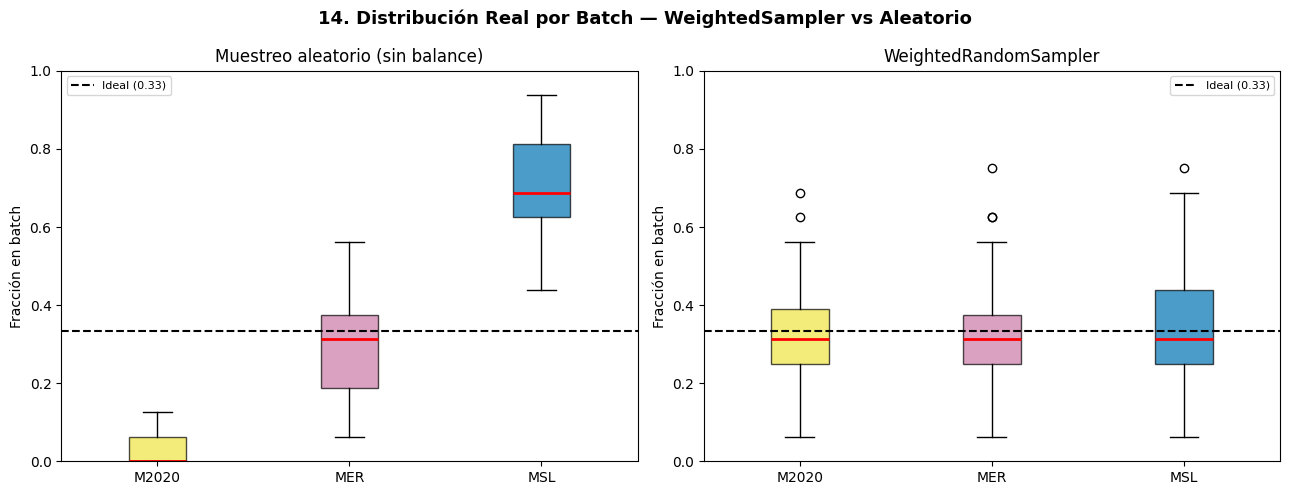


Media ± std de fracción por misión en batch:

  [Aleatorio]
    M2020: 0.020 ± 0.033
    MER: 0.285 ± 0.116
    MSL: 0.695 ± 0.118

  [Weighted]
    M2020: 0.332 ± 0.114
    MER: 0.329 ± 0.118
    MSL: 0.340 ± 0.121

──────────────────────────────────────────────────────────
NOTA IMPORTANTE: el balanceo es POR MISIÓN, no por clase.
Estas dos dimensiones son ortogonales: es posible tener
batches balanceados en misión y aún así desbalanceados en
clases (big_rock sigue siendo raro en todos los batches).
El WeightedCE con ignore_index=255 maneja el desbalance
de clases de forma complementaria al sampler.
──────────────────────────────────────────────────────────
[D] Decisión: usar WeightedSampler (misión) + WeightedCE
    (clases) como estrategia dual de balanceo.
[A] Impacto: M2020 pasa de aparecer <1 vez cada 6 batches
    a ~5 veces por batch → el modelo aprende de ella.
[R] Riesgo: oversampling con replacement puede generar
    repetición de MSL → monitorear loss por misión.
─────────

In [49]:
def simulate_weighted_sampling(df, n_batches=200, batch_size=16, seed=42):
    mission_counts = df["mission"].value_counts().to_dict()
    weights = df["mission"].map(lambda m: 1.0/mission_counts[m]).values
    weights /= weights.sum()
    rng = np.random.default_rng(seed)
    return [
        df.iloc[rng.choice(len(df), size=batch_size, replace=True, p=weights)
               ]["mission"].value_counts(normalize=True).to_dict()
        for _ in range(n_batches)
    ]
 
def simulate_uniform_sampling(df, n_batches=200, batch_size=16, seed=42):
    rng = np.random.default_rng(seed)
    return [
        df.iloc[rng.choice(len(df), size=batch_size, replace=False)
               ]["mission"].value_counts(normalize=True).to_dict()
        for _ in range(n_batches)
    ]
 
print("\nSimulando batches (200 iteraciones)...")
weighted_batches = simulate_weighted_sampling(df_clean)
uniform_batches  = simulate_uniform_sampling(df_clean)
missions_all     = sorted(df_clean["mission"].unique())
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("14. Distribución Real por Batch — WeightedSampler vs Aleatorio",
             fontsize=13, fontweight="bold")
 
for ax, batches, title in zip(axes,
    [uniform_batches, weighted_batches],
    ["Muestreo aleatorio (sin balance)", "WeightedRandomSampler"]):
    bp = ax.boxplot(
        [[b.get(m,0) for b in batches] for m in missions_all],
        labels=missions_all, patch_artist=True,
        medianprops=dict(color="red", linewidth=2)
    )
    for patch, m in zip(bp["boxes"], missions_all):
        patch.set_facecolor(MISSION_COLORS[m]); patch.set_alpha(0.7)
    ax.axhline(1/len(missions_all), color="black", linestyle="--",
               linewidth=1.5, label=f"Ideal ({1/len(missions_all):.2f})")
    ax.set_ylabel("Fracción en batch"); ax.set_title(title)
    ax.legend(fontsize=8); ax.set_ylim(0, 1)
 
plt.tight_layout()
plt.savefig("processed/eda_14_batch_balance.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nMedia ± std de fracción por misión en batch:")
for title, batches in [("Aleatorio", uniform_batches), ("Weighted", weighted_batches)]:
    print(f"\n  [{title}]")
    for m in missions_all:
        vals = [b.get(m,0) for b in batches]
        print(f"    {m}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")
 
print("""
──────────────────────────────────────────────────────────
NOTA IMPORTANTE: el balanceo es POR MISIÓN, no por clase.
Estas dos dimensiones son ortogonales: es posible tener
batches balanceados en misión y aún así desbalanceados en
clases (big_rock sigue siendo raro en todos los batches).
El WeightedCE con ignore_index=255 maneja el desbalance
de clases de forma complementaria al sampler.
──────────────────────────────────────────────────────────
[D] Decisión: usar WeightedSampler (misión) + WeightedCE
    (clases) como estrategia dual de balanceo.
[A] Impacto: M2020 pasa de aparecer <1 vez cada 6 batches
    a ~5 veces por batch → el modelo aprende de ella.
[R] Riesgo: oversampling con replacement puede generar
    repetición de MSL → monitorear loss por misión.
──────────────────────────────────────────────────────────
""")

In [50]:
from scipy.stats import ks_2samp


Analizando intensidad por clase (sampling estratificado)...


Intensidad por clase: 100%|██████████| 300/300 [00:06<00:00, 49.10it/s]


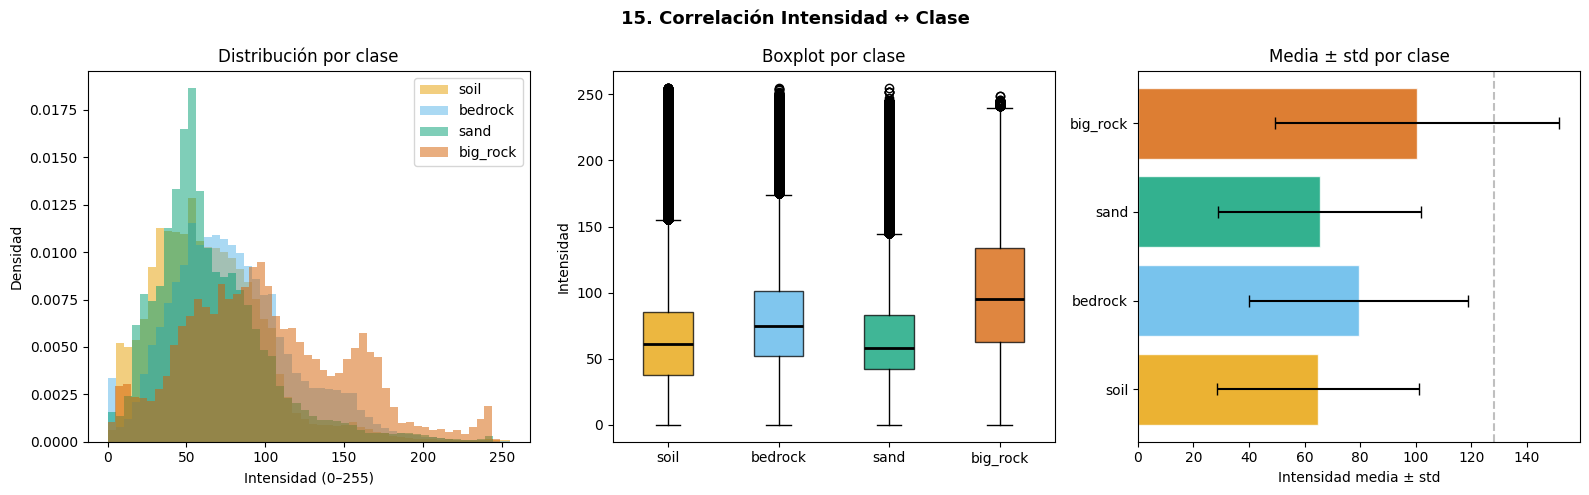


── Kolmogorov-Smirnov test de separabilidad (intensidad) ──
Par                     KS stat       p-valor  Interpretación
─────────────────────────────────────────────────────────────────
soil       vs bedrock       0.1566      0.00e+00  ✅ distribuciones distintas (moderado)
soil       vs sand          0.0446     3.74e-142  ✅ distribuciones distintas (solapamiento)
soil       vs big_rock      0.3338      0.00e+00  ✅ distribuciones distintas (muy separadas)
bedrock    vs sand          0.1987      0.00e+00  ✅ distribuciones distintas (moderado)
bedrock    vs big_rock      0.1976      0.00e+00  ✅ distribuciones distintas (moderado)
sand       vs big_rock      0.3514      0.00e+00  ✅ distribuciones distintas (muy separadas)

──────────────────────────────────────────────────────────
[D] Decisión: KS p < 0.05 confirma que las distribuciones
    son estadísticamente distintas → la intensidad tiene
    poder discriminativo. Sin embargo, KS stat < 0.3 en
    pares similares indica solapamient

In [51]:
def intensity_per_class(df, n_per_mission=100, px_per_img=2000, seed=42):
    records = []
    rng = np.random.default_rng(seed)
    sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)
 
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Intensidad por clase"):
        img  = np.array(Image.open(row["image_path"]).convert("L"))
        mask = np.array(Image.open(row["mask_path"]))
        valid_idx = np.where(mask != 255)
        if len(valid_idx[0]) == 0:
            continue
        n = min(px_per_img, len(valid_idx[0]))
        chosen = rng.choice(len(valid_idx[0]), size=n, replace=False)
        rows_px = valid_idx[0][chosen]
        cols_px = valid_idx[1][chosen]
        for intensity, cls in zip(img[rows_px, cols_px], mask[rows_px, cols_px]):
            if cls in [0,1,2,3]:
                records.append({"intensity": int(intensity), "class": int(cls),
                                 "class_name": CLASS_COLORS[int(cls)][1]})
    return pd.DataFrame(records)
 
print("\nAnalizando intensidad por clase (sampling estratificado)...")
df_intensity = intensity_per_class(df_clean, n_per_mission=100)
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("15. Correlación Intensidad ↔ Clase", fontsize=13, fontweight="bold")
 
for cls in [0,1,2,3]:
    sub = df_intensity[df_intensity["class"]==cls]["intensity"]
    if len(sub) > 10:
        axes[0].hist(sub, bins=50, alpha=0.5, density=True,
                     color=CLASS_COLORS[cls][0], label=CLASS_COLORS[cls][1])
axes[0].set_xlabel("Intensidad (0–255)"); axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución por clase"); axes[0].legend()
 
bp_data = [df_intensity[df_intensity["class"]==c]["intensity"].values for c in [0,1,2,3]]
bp = axes[1].boxplot(bp_data, labels=class_names, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, cls in zip(bp["boxes"], [0,1,2,3]):
    patch.set_facecolor(CLASS_COLORS[cls][0]); patch.set_alpha(0.75)
axes[1].set_ylabel("Intensidad"); axes[1].set_title("Boxplot por clase")
 
stats = df_intensity.groupby("class")["intensity"].agg(["mean","std"])
stats.index = class_names
axes[2].barh(stats.index, stats["mean"], xerr=stats["std"],
             color=[CLASS_COLORS[c][0] for c in [0,1,2,3]],
             alpha=0.8, edgecolor="white", capsize=4)
axes[2].set_xlabel("Intensidad media ± std"); axes[2].set_title("Media ± std por clase")
axes[2].axvline(128, color="gray", linestyle="--", alpha=0.5)
 
plt.tight_layout()
plt.savefig("processed/eda_15_intensity_class.png", dpi=150, bbox_inches="tight")
plt.show()
 
# KS-test entre pares de clases
print("\n── Kolmogorov-Smirnov test de separabilidad (intensidad) ──")
print(f"{'Par':<22} {'KS stat':>8}  {'p-valor':>12}  {'Interpretación'}")
print("─" * 65)
for i in range(4):
    for j in range(i+1, 4):
        s1 = df_intensity[df_intensity["class"]==i]["intensity"].values
        s2 = df_intensity[df_intensity["class"]==j]["intensity"].values
        if len(s1) > 0 and len(s2) > 0:
            ks = ks_2samp(s1, s2)
            sig  = "✅ distribuciones distintas" if ks.pvalue < 0.05 else "⚠️ solapamiento alto"
            high = " (muy separadas)" if ks.statistic > 0.3 else (" (moderado)" if ks.statistic > 0.15 else " (solapamiento)")
            print(f"{CLASS_COLORS[i][1]:10} vs {CLASS_COLORS[j][1]:10}  "
                  f"{ks.statistic:>8.4f}  {ks.pvalue:>12.2e}  {sig}{high}")
 
print("""
──────────────────────────────────────────────────────────
[D] Decisión: KS p < 0.05 confirma que las distribuciones
    son estadísticamente distintas → la intensidad tiene
    poder discriminativo. Sin embargo, KS stat < 0.3 en
    pares similares indica solapamiento → el modelo necesita
    contexto espacial, no solo información puntual de píxel.
[A] Impacto: justifica CNNs (capturan textura local) y
    arquitecturas con ASPP/atrous (contexto global).
    Un clasificador por píxel puro (sin contexto) fallará
    en las clases con alta superposición de intensidades.
[R] Riesgo: alta separabilidad estadística no implica
    separabilidad visual — siempre validar con inspección
    cualitativa (sección 6).
──────────────────────────────────────────────────────────
""")
 
print("✅ EDA parte 3 completo. Todas las correcciones aplicadas.")
print("   - Bordes: np.pad (sin wrap-around)")
print("   - Sampling: estratificado por misión")
print("   - KS-test: separabilidad cuantificada")
print("   - Balance: dimensiones misión/clase documentadas")



Generando visualización cualitativa de bordes detectados...


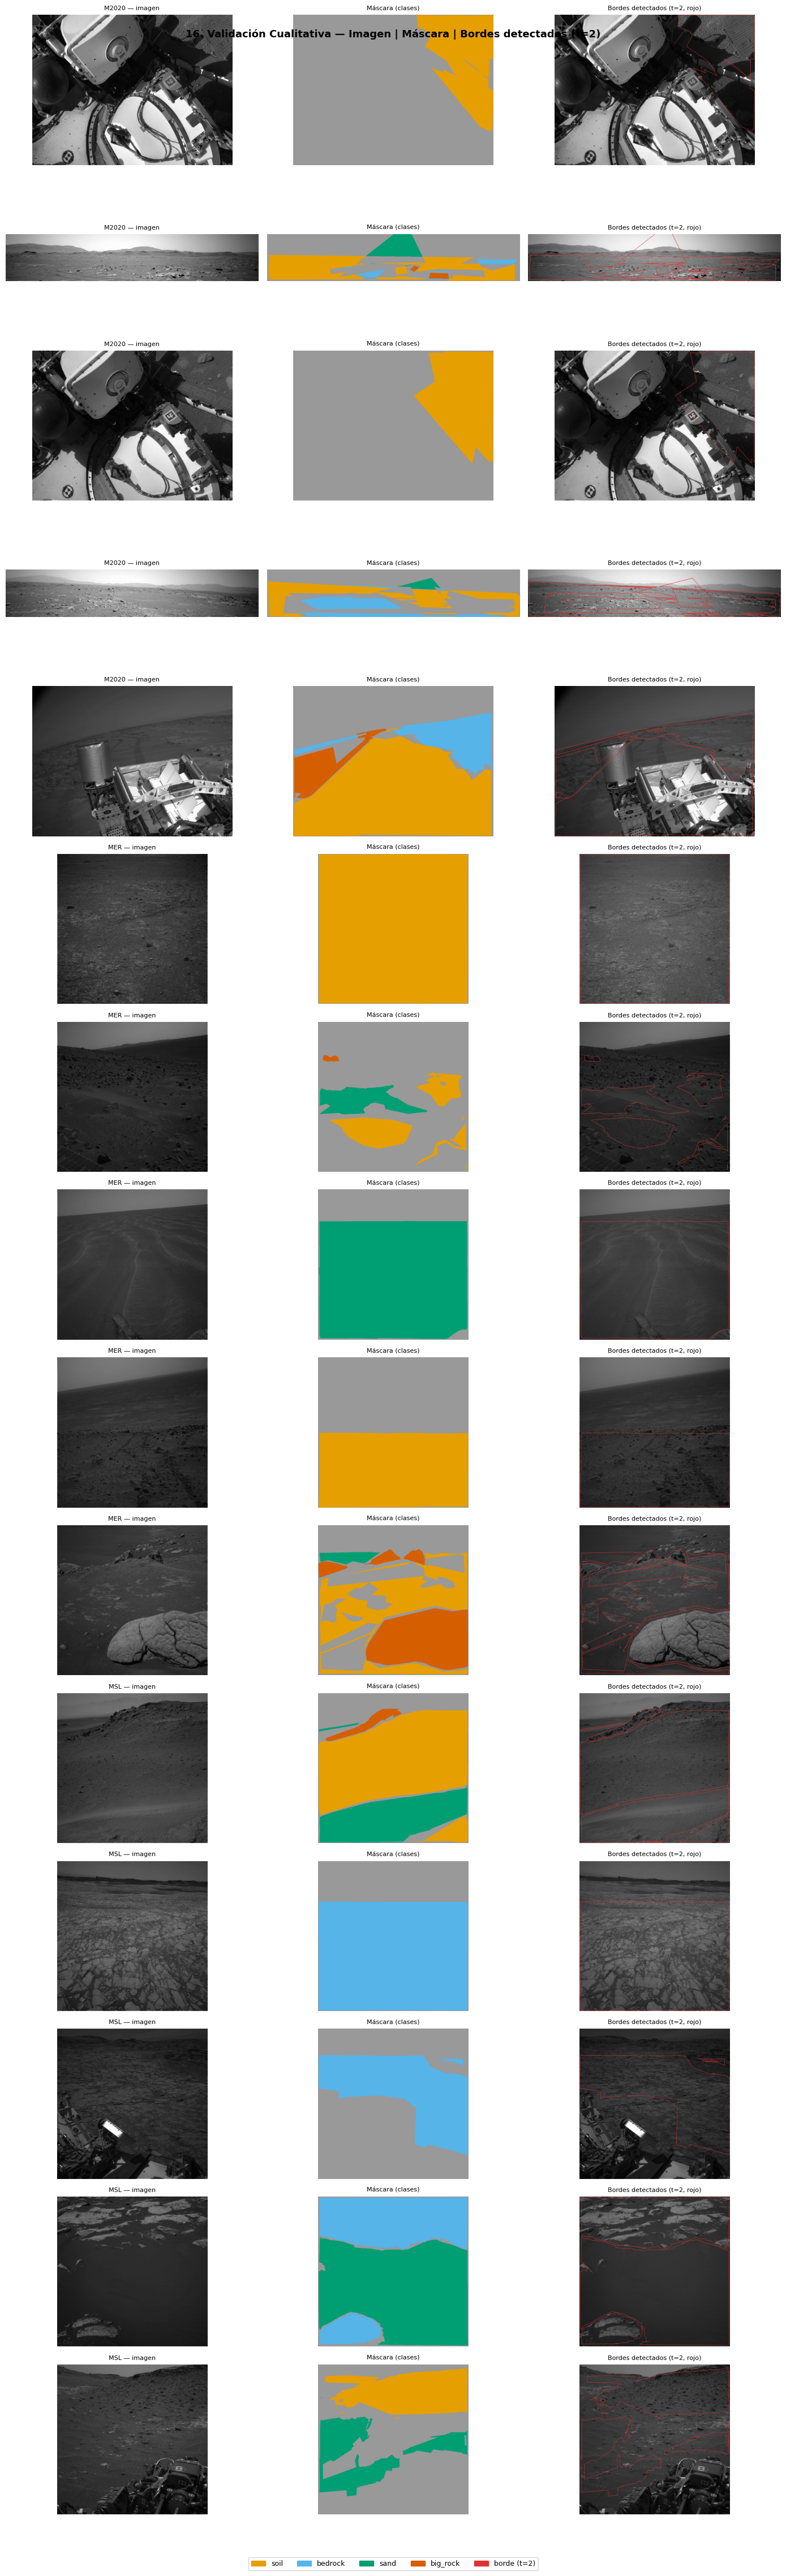

✅ Visualización cualitativa guardada.

╔══════════════════════════════════════════════════════════════════════════════╗
║         TABLA RESUMEN: HALLAZGO EDA → DECISIÓN ARQUITECTÓNICA               ║
╠══════════════════════════════╦═════════════════════════╦════════════════════╣
║ Hallazgo                     ║ Decisión arquitectónica ║ Componente         ║
╠══════════════════════════════╬═════════════════════════╬════════════════════╣
║ big_rock = 0.4% píxeles      ║ Focal Loss / WeightedCE ║ Función de pérdida ║
║ big_rock en <10% imágenes    ║ Hard example mining     ║ Sampler            ║
║ Bordes = >X% de píxeles      ║ Dice Loss (0.5 CE+Dice) ║ Función de pérdida ║
║ Solapamiento de intensidades ║ Contexto espacial (ASPP)║ Arquitectura       ║
║ Domain shift JS>0.15         ║ Eval. cross-mission     ║ Protocolo eval.    ║
║ M2020 subrepresentada (2%)   ║ WeightedRandomSampler   ║ DataLoader         ║
║ ignore=45% de píxeles        ║ ignore_index=255        ║ Loss               ║


In [52]:
print("\nGenerando visualización cualitativa de bordes detectados...")
 
sample_viz = stratified_sample(df_clean, n_per_mission=5, seed=99)
 
fig, axes = plt.subplots(len(sample_viz), 3, figsize=(14, len(sample_viz)*3))
fig.suptitle("16. Validación Cualitativa — Imagen | Máscara | Bordes detectados (t=2)",
             fontsize=13, fontweight="bold")
 
if len(sample_viz) == 1:
    axes = [axes]
 
for row_idx, (_, row) in enumerate(sample_viz.iterrows()):
    img  = np.array(Image.open(row["image_path"]).convert("L"))
    mask = np.array(Image.open(row["mask_path"]))
 
    border_t2 = detect_border_pixels(mask, thickness=2)
    valid = (mask != 255)
 
    # Columna 0: imagen original
    axes[row_idx][0].imshow(img, cmap="gray")
    axes[row_idx][0].set_title(f"{row['mission']} — imagen", fontsize=8)
    axes[row_idx][0].axis("off")
 
    # Columna 1: máscara con colores por clase
    mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c, (color, _) in CLASS_COLORS.items():
        r = int(color[1:3], 16)
        g = int(color[3:5], 16)
        b = int(color[5:7], 16)
        mask_rgb[mask == c] = [r, g, b]
    axes[row_idx][1].imshow(mask_rgb)
    axes[row_idx][1].set_title("Máscara (clases)", fontsize=8)
    axes[row_idx][1].axis("off")
 
    # Columna 2: imagen + overlay de bordes (thickness=2) en rojo
    overlay = np.stack([img, img, img], axis=-1)
    overlay[border_t2 & valid] = [220, 50, 50]   # rojo = borde
    axes[row_idx][2].imshow(overlay)
    axes[row_idx][2].set_title("Bordes detectados (t=2, rojo)", fontsize=8)
    axes[row_idx][2].axis("off")
 
# Leyenda de clases
patches = [mpatches.Patch(color=CLASS_COLORS[c][0], label=CLASS_COLORS[c][1])
           for c in [0,1,2,3]]
patches.append(mpatches.Patch(color="#DC3232", label="borde (t=2)"))
fig.legend(handles=patches, loc="lower center", ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
 
plt.tight_layout()
plt.savefig("processed/eda_16_qualitative_borders.png", dpi=130, bbox_inches="tight")
plt.show()
 
print("✅ Visualización cualitativa guardada.")
 
 
# ══════════════════════════════════════════════════════════════════════════════
# 17. TABLA CIERRE: HALLAZGO → DECISIÓN ARQUITECTÓNICA
# ══════════════════════════════════════════════════════════════════════════════
 
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║         TABLA RESUMEN: HALLAZGO EDA → DECISIÓN ARQUITECTÓNICA               ║
╠══════════════════════════════╦═════════════════════════╦════════════════════╣
║ Hallazgo                     ║ Decisión arquitectónica ║ Componente         ║
╠══════════════════════════════╬═════════════════════════╬════════════════════╣
║ big_rock = 0.4% píxeles      ║ Focal Loss / WeightedCE ║ Función de pérdida ║
║ big_rock en <10% imágenes    ║ Hard example mining     ║ Sampler            ║
║ Bordes = >X% de píxeles      ║ Dice Loss (0.5 CE+Dice) ║ Función de pérdida ║
║ Solapamiento de intensidades ║ Contexto espacial (ASPP)║ Arquitectura       ║
║ Domain shift JS>0.15         ║ Eval. cross-mission     ║ Protocolo eval.    ║
║ M2020 subrepresentada (2%)   ║ WeightedRandomSampler   ║ DataLoader         ║
║ ignore=45% de píxeles        ║ ignore_index=255        ║ Loss               ║
║ Múltiples resoluciones       ║ Resize 256 + NEAREST    ║ Preprocesamiento   ║
║ Bordes ruidosos en etiquetas ║ Skip connections        ║ UNet / DeepLabV3+  ║
╚══════════════════════════════╩═════════════════════════╩════════════════════╝
""")
 
summary_final = pd.DataFrame({
    "Hallazgo": [
        "big_rock = 0.4% de píxeles",
        "big_rock en <10% de imágenes",
        f"Bordes = {np.median(thickness_results[2])*100:.1f}% con t=2",
        "Solapamiento de intensidades (KS < 0.3 en pares similares)",
        f"Domain shift JS > 0.15 entre misiones",
        "M2020 = 2% del dataset",
        "ignore = 45% de píxeles",
        "Múltiples resoluciones de imagen",
        f"Baseline C empírico = {miou_c:.4f}",
    ],
    "Decisión": [
        "Focal Loss γ=2 / WeightedCE",
        "WeightedSampler + oversampling imágenes con clase",
        "Loss = 0.5·CE + 0.5·Dice",
        "Arquitectura con ASPP (DeepLabV3+) o skip connections",
        "Evaluar por misión + experimento cross-mission",
        "WeightedRandomSampler por misión",
        "CrossEntropyLoss(ignore_index=255)",
        "Resize 256×256, NEAREST para máscaras",
        "Cualquier modelo debe superar este mIoU",
    ],
    "Componente": [
        "Loss", "Sampler", "Loss", "Arquitectura",
        "Protocolo", "DataLoader", "Loss",
        "Preprocesamiento", "Benchmark",
    ]
})
 
summary_final.to_csv("processed/eda_summary_final.csv", index=False)
print(summary_final.to_string(index=False))
print(f"\n✅ Tabla guardada en processed/eda_summary_final.csv")
print(f"\n{'='*60}")
print(f"EDA COMPLETADO — {len(summary_final)} decisiones de diseño justificadas.")
print(f"Baseline empírico de referencia: mIoU_C = {miou_c:.4f}")
print(f"Objetivo estimado: mIoU ∈ [0.35, 0.55]")
print(f"{'='*60}")

POST - EDA


In [53]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [54]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"] = str(seed)

In [55]:
NUM_CLASSES  = 4
IGNORE_INDEX = 255
 
CLASS_NAMES = {0: "soil", 1: "bedrock", 2: "sand", 3: "big_rock"}
 
# Pesos de clase calculados del EDA (1/freq sobre clases válidas, normalizado)
# soil~0.38, bedrock~0.40, sand~0.20, big_rock~0.007  → pesos inversos
DEFAULT_CLASS_WEIGHTS = torch.tensor([0.87, 0.83, 1.65, 33.2], dtype=torch.float32)

In [56]:
IMG_MEAN = (0.456, 0.456, 0.456)   # canal gris replicado ×3
IMG_STD  = (0.224, 0.224, 0.224)
 
def get_train_transforms(img_size: int = 256):
    return A.Compose([
        A.Resize(img_size, img_size, interpolation=1),   # BILINEAR para imagen
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=IMG_MEAN, std=IMG_STD),
        ToTensorV2(),
    ], additional_targets={"mask": "mask"})
 
def get_val_transforms(img_size: int = 256):
    return A.Compose([
        A.Resize(img_size, img_size, interpolation=1),
        A.Normalize(mean=IMG_MEAN, std=IMG_STD),
        ToTensorV2(),
    ], additional_targets={"mask": "mask"})

In [57]:
class MarsDataset(Dataset):
    """
    Parámetros
    ----------
    df          : DataFrame con columnas [image_path, mask_path, mission]
    transform   : albumentations Compose (imagen + máscara juntas)
    img_size    : tamaño cuadrado destino
 
    Nota: máscara resizeada con NEAREST (cv2=0) para no interpolar etiquetas.
    """
 
    def __init__(self, df: pd.DataFrame, transform=None, img_size: int = 256):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.img_size  = img_size
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
 
        # imagen → RGB (canal gris replicado ×3 para backbones ImageNet)
        img  = np.array(Image.open(row["image_path"]).convert("RGB"))
        # máscara → sin conversión (valores 0-3 y 255)
        mask = np.array(Image.open(row["mask_path"]).convert("L"))
 
        # resize máscara con NEAREST (interpolación=0) antes del Compose
        mask_pil = Image.fromarray(mask).resize(
            (self.img_size, self.img_size), Image.NEAREST
        )
        mask = np.array(mask_pil)
 
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]    # Tensor [3, H, W]
            mask = aug["mask"]     # Tensor [H, W]
        else:
            img  = torch.from_numpy(img.transpose(2,0,1)).float() / 255.0
            mask = torch.from_numpy(mask)
 
        return img, mask.long(), row["mission"]

In [58]:
def split_manifest(
    df: pd.DataFrame,
    train_ratio: float = 0.70,
    val_ratio:   float = 0.15,
    seed: int = 42,
) -> tuple:
    """Split estratificado por misión (70/15/15)."""
    train_f, val_f, test_f = [], [], []
 
    for _, group in df.groupby("mission"):
        g = group.sample(frac=1, random_state=seed)
        n = len(g)
        n_tr = int(n * train_ratio)
        n_va = int(n * val_ratio)
        train_f.append(g.iloc[:n_tr])
        val_f.append(  g.iloc[n_tr : n_tr + n_va])
        test_f.append( g.iloc[n_tr + n_va :])
 
    df_tr = pd.concat(train_f).sample(frac=1, random_state=seed).reset_index(drop=True)
    df_va = pd.concat(val_f  ).sample(frac=1, random_state=seed).reset_index(drop=True)
    df_te = pd.concat(test_f ).sample(frac=1, random_state=seed).reset_index(drop=True)
 
    print(f"Train : {len(df_tr):>5}  {df_tr['mission'].value_counts().to_dict()}")
    print(f"Val   : {len(df_va):>5}  {df_va['mission'].value_counts().to_dict()}")
    print(f"Test  : {len(df_te):>5}  {df_te['mission'].value_counts().to_dict()}")
    return df_tr, df_va, df_te
 

In [59]:
def make_weighted_sampler(df: pd.DataFrame) -> WeightedRandomSampler:
    counts  = df["mission"].value_counts().to_dict()
    weights = torch.DoubleTensor(
        df["mission"].map(lambda m: 1.0 / counts[m]).values
    )
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

In [60]:
def build_dataloaders(
    df_train, df_val, df_test,
    img_size:    int  = 256,
    batch_size:  int  = 16,
    num_workers: int  = 4,
    balance_missions: bool = True,
):
    train_ds = MarsDataset(df_train, get_train_transforms(img_size), img_size)
    val_ds   = MarsDataset(df_val,   get_val_transforms(img_size),   img_size)
    test_ds  = MarsDataset(df_test,  get_val_transforms(img_size),   img_size)
 
    sampler = make_weighted_sampler(df_train) if balance_missions else None
 
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              sampler=sampler, shuffle=(sampler is None),
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader

In [61]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes=4, ignore_index=255, smooth=1.0):
        super().__init__()
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.smooth       = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        valid = (targets != self.ignore_index)
        dice  = 0.0
        n_present = 0
        for c in range(self.num_classes):
            t = (targets[valid] == c).float()
            if t.sum() == 0:
                continue  # skip clases ausentes en el batch
            p = probs[:, c][valid]
            intersection = (p * t).sum()
            dice += (2 * intersection + self.smooth) / (p.sum() + t.sum() + self.smooth)
            n_present += 1
        return 1.0 - dice / max(n_present, 1)
 
 
class SegLoss(nn.Module):
    """
    Loss combinada: α·WeightedCE + (1-α)·Dice
    Ambas con ignore_index=255.
    """
 
    def __init__(
        self,
        class_weights: torch.Tensor = DEFAULT_CLASS_WEIGHTS,
        alpha: float = 0.5,
        ignore_index: int = IGNORE_INDEX,
        device: str = "cpu",
    ):
        super().__init__()
        self.alpha = alpha
        self.ce    = nn.CrossEntropyLoss(
            weight=class_weights.to(device),
            ignore_index=ignore_index,
        )
        self.dice  = DiceLoss(ignore_index=ignore_index)
 
    def forward(self, logits, targets):
        return self.alpha * self.ce(logits, targets) + \
               (1 - self.alpha) * self.dice(logits, targets)

In [62]:
class SegMetrics:
    """
    Acumula TP, FP, FN por clase a lo largo de un epoch.
    Llamar .update() en cada batch y .compute() al final.
    ignore_index=255 excluido automáticamente.
    """
 
    def __init__(self, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.reset()
 
    def reset(self):
        self.tp = np.zeros(self.num_classes, dtype=np.int64)
        self.fp = np.zeros(self.num_classes, dtype=np.int64)
        self.fn = np.zeros(self.num_classes, dtype=np.int64)
        self.correct_px = 0
        self.total_px   = 0
 
    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        preds   : [B, C, H, W] logits  o  [B, H, W] clase predicha
        targets : [B, H, W] LongTensor
        """
        if preds.dim() == 4:
            preds = preds.argmax(dim=1)
 
        preds   = preds.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()
 
        valid = targets != self.ignore_index
        preds, targets = preds[valid], targets[valid]
 
        self.correct_px += int((preds == targets).sum())
        self.total_px   += int(valid.sum())
 
        for c in range(self.num_classes):
            pred_c   = preds   == c
            target_c = targets == c
            self.tp[c] += int(( pred_c &  target_c).sum())
            self.fp[c] += int(( pred_c & ~target_c).sum())
            self.fn[c] += int((~pred_c &  target_c).sum())
 
    def compute(self) -> dict:
        iou_per_class = {}
        dice_per_class = {}
 
        for c in range(self.num_classes):
            denom_iou  = self.tp[c] + self.fp[c] + self.fn[c]
            denom_dice = 2*self.tp[c] + self.fp[c] + self.fn[c]
            iou_per_class[CLASS_NAMES[c]]  = self.tp[c] / denom_iou  if denom_iou  > 0 else 0.0
            dice_per_class[CLASS_NAMES[c]] = 2*self.tp[c] / denom_dice if denom_dice > 0 else 0.0
 
        miou  = float(np.mean(list(iou_per_class.values())))
        mdice = float(np.mean(list(dice_per_class.values())))
        pixel_acc = self.correct_px / max(self.total_px, 1)
 
        return {
            "mIoU":         miou,
            "mDice":        mdice,
            "pixel_acc":    pixel_acc,
            "iou_per_class":  iou_per_class,
            "dice_per_class": dice_per_class,
        }

In [63]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    metrics    = SegMetrics()
 
    for imgs, masks, _ in loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)
 
        optimizer.zero_grad()
 
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss   = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss   = criterion(logits, masks)
            loss.backward()
            optimizer.step()
 
        total_loss += loss.item()
        metrics.update(logits.detach(), masks)
 
    results = metrics.compute()
    results["loss"] = total_loss / len(loader)
    return results
 
 
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    metrics    = SegMetrics()
 
    for imgs, masks, _ in loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, masks).item()
        metrics.update(logits, masks)
 
    results = metrics.compute()
    results["loss"] = total_loss / len(loader)
    return results

In [64]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    device: str = "cpu",
    epochs: int = 50,
    patience: int = 10,
    save_path: str = "best_model.pth",
    use_amp: bool = False,
    run_id: int = 0,
):
    """
    Loop completo con:
      - Early stopping (patience epochs sin mejora en val mIoU)
      - Guarda el mejor modelo
      - Retorna historial completo de métricas
      - Soporte AMP (mixed precision) si use_amp=True y GPU disponible
    """
    scaler  = torch.cuda.amp.GradScaler() if use_amp and device != "cpu" else None
    history = {"train": [], "val": []}
    best_miou = -1.0
    no_improve = 0
 
    print(f"\n{'='*60}")
    print(f"RUN {run_id} | device={device} | epochs={epochs} | patience={patience}")
    print(f"{'='*60}")
 
    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
        va = evaluate(model, val_loader, criterion, device)
 
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va["mIoU"])
            else:
                scheduler.step()
 
        history["train"].append(tr)
        history["val"].append(va)
 
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train loss={tr['loss']:.4f} mIoU={tr['mIoU']:.4f} | "
              f"val   loss={va['loss']:.4f} mIoU={va['mIoU']:.4f} "
              f"[big_rock IoU={va['iou_per_class']['big_rock']:.4f}]")
 
        if va["mIoU"] > best_miou:
            best_miou = va["mIoU"]
            no_improve = 0
            torch.save({"epoch": epoch,
                        "model_state": model.state_dict(),
                        "val_metrics": va,
                        "run_id": run_id}, save_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping en epoch {epoch} (patience={patience})")
                break
 
    print(f"Mejor val mIoU = {best_miou:.4f}  (guardado en {save_path})")
    return history, best_miou

In [65]:
def run_experiment(
    model_fn,           # callable() → modelo nuevo (sin estado)
    df_train, df_val, df_test,
    experiment_name: str = "exp",
    seeds: list = [42, 123, 7],
    epochs: int = 50,
    batch_size: int = 16,
    lr: float = 1e-4,
    img_size: int = 256,
    balance_missions: bool = True,
    alpha_loss: float = 0.5,
    device: str = "cpu",
    save_dir: str = "checkpoints",
    num_workers: int = 4,
):
    """
    Ejecuta el experimento con N seeds distintas.
    Retorna media ± std de métricas de test (requisito del entregable).
    """
    Path(save_dir).mkdir(parents=True, exist_ok=True)
 
    all_test_metrics = []
 
    for run_id, seed in enumerate(seeds):
        set_seed(seed)
        print(f"\n{'─'*50}")
        print(f"EXPERIMENTO: {experiment_name} | Seed {seed} ({run_id+1}/{len(seeds)})")
 
        train_loader, val_loader, test_loader = build_dataloaders(
            df_train, df_val, df_test,
            img_size=img_size,
            batch_size=batch_size,
            num_workers=num_workers,
            balance_missions=balance_missions,
        )
 
        model     = model_fn().to(device)
        criterion = SegLoss(alpha=alpha_loss, device=device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=1e-6
        )
 
        save_path = f"{save_dir}/{experiment_name}_seed{seed}.pth"
        history, best_miou = train_model(
            model, train_loader, val_loader, criterion, optimizer, scheduler,
            device=device, epochs=epochs, patience=10,
            save_path=save_path, run_id=run_id,
        )
 
        # Cargar mejor checkpoint y evaluar en test
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        test_metrics = evaluate(model, test_loader, criterion, device)
        test_metrics["seed"] = seed
        all_test_metrics.append(test_metrics)
 
        print(f"Test mIoU = {test_metrics['mIoU']:.4f}")
 
    # Resumen estadístico
    miou_vals   = [m["mIoU"]     for m in all_test_metrics]
    dice_vals   = [m["mDice"]    for m in all_test_metrics]
    acc_vals    = [m["pixel_acc"] for m in all_test_metrics]
 
    summary = {
        "experiment":     experiment_name,
        "mIoU_mean":      float(np.mean(miou_vals)),
        "mIoU_std":       float(np.std(miou_vals)),
        "mIoU_ci95":      float(1.96 * np.std(miou_vals) / np.sqrt(len(miou_vals))),
        "mDice_mean":     float(np.mean(dice_vals)),
        "pixel_acc_mean": float(np.mean(acc_vals)),
        "per_run":        all_test_metrics,
    }
 
    # IoU por clase — media ± std
    for c_name in CLASS_NAMES.values():
        vals = [m["iou_per_class"][c_name] for m in all_test_metrics]
        summary[f"iou_{c_name}_mean"] = float(np.mean(vals))
        summary[f"iou_{c_name}_std"]  = float(np.std(vals))
 
    print(f"\n{'='*60}")
    print(f"RESUMEN {experiment_name}")
    print(f"  mIoU : {summary['mIoU_mean']:.4f} ± {summary['mIoU_std']:.4f}"
          f"  (IC95: ±{summary['mIoU_ci95']:.4f})")
    print(f"  mDice: {summary['mDice_mean']:.4f}")
    print(f"  Acc  : {summary['pixel_acc_mean']:.4f}")
    for c_name in CLASS_NAMES.values():
        print(f"  IoU({c_name}): "
              f"{summary[f'iou_{c_name}_mean']:.4f} ± {summary[f'iou_{c_name}_std']:.4f}")
    print(f"{'='*60}")
 
    return summary


In [66]:
import cv2

def get_train_transforms(img_size=256):
    return A.Compose([
        A.Resize(img_size, img_size,
                 interpolation=cv2.INTER_LINEAR,
                 mask_interpolation=cv2.INTER_NEAREST),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=(0.456, 0.456, 0.456), std=(0.224, 0.224, 0.224)),
        ToTensorV2(),
    ])

def get_val_transforms(img_size=256):
    return A.Compose([
        A.Resize(img_size, img_size,
                 interpolation=cv2.INTER_LINEAR,
                 mask_interpolation=cv2.INTER_NEAREST),
        A.Normalize(mean=(0.456, 0.456, 0.456), std=(0.224, 0.224, 0.224)),
        ToTensorV2(),
    ])

class MarsDataset(Dataset):
    def __init__(self, df, transform=None, img_size=256):
        self.df        = df.reset_index(drop=True)
        self.transform = transform if transform is not None else get_val_transforms(img_size)
        self.img_size  = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = np.array(Image.open(row["image_path"]).convert("RGB"))
        mask = np.array(Image.open(row["mask_path"]).convert("L"))
        aug  = self.transform(image=img, mask=mask)
        return aug["image"], aug["mask"].long(), row["mission"]

In [67]:
df = pd.read_csv("processed/manifest_clean.csv")
df_train, df_val, df_test = split_manifest(df)

train_loader, val_loader, test_loader = build_dataloaders(
    df_train, df_val, df_test,
    img_size=256, batch_size=4, num_workers=0
)

imgs, masks, missions = next(iter(train_loader))
print(f"imgs : {imgs.shape}  dtype={imgs.dtype}")
print(f"masks: {masks.shape}  dtype={masks.dtype}")
print(f"misiones: {list(missions)}")
print(f"valores únicos en máscara: {masks.unique().tolist()}")

Train : 16074  {'MSL': 11130, 'MER': 4615, 'M2020': 329}
Val   :  3443  {'MSL': 2385, 'MER': 988, 'M2020': 70}
Test  :  3448  {'MSL': 2386, 'MER': 990, 'M2020': 72}
imgs : torch.Size([4, 3, 256, 256])  dtype=torch.float32
masks: torch.Size([4, 256, 256])  dtype=torch.int64
misiones: ['MER', 'MER', 'MER', 'MER']
valores únicos en máscara: [0, 1, 2, 255]


In [69]:
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = SegLoss(device=device)
dummy_logits = torch.randn(4, NUM_CLASSES, 256, 256).to(device)  # ← agregar .to(device)
masks_device = masks.to(device)                                    # ← mover máscaras también
loss = criterion(dummy_logits, masks_device)
print(f"Loss test: {loss.item():.4f}")

m = SegMetrics()
m.update(dummy_logits, masks_device)
print(m.compute())

Loss test: 1.2614
{'mIoU': 0.11559279780798283, 'mDice': 0.19846640725672254, 'pixel_acc': 0.24988553199474572, 'iou_per_class': {'soil': np.float64(0.16740088105726872), 'bedrock': np.float64(0.20758079981950478), 'sand': np.float64(0.009225738642998948), 'big_rock': np.float64(0.07816377171215881)}, 'dice_per_class': {'soil': np.float64(0.28679245283018867), 'bedrock': np.float64(0.3437961250303608), 'sand': np.float64(0.018282804906271696), 'big_rock': np.float64(0.14499424626006904)}}


In [71]:
if __name__ == "__main__":
    set_seed(42)
    df = pd.read_csv("processed/manifest_clean.csv")
    df_train, df_val, df_test = split_manifest(df)
 
    train_loader, val_loader, test_loader = build_dataloaders(
        df_train, df_val, df_test,
        img_size=256, batch_size=4, num_workers=0
    )
 
    imgs, masks, missions = next(iter(train_loader))
    print(f"Batch OK → imgs: {imgs.shape}  masks: {masks.shape}")
    print(f"Valores únicos en máscara: {masks.unique().tolist()}")
 
    # Test loss
    device    = "cuda" if torch.cuda.is_available() else "cpu"
    criterion = SegLoss(device=device)
    dummy_logits = torch.randn(4, NUM_CLASSES, 256, 256)
    loss = criterion(dummy_logits, masks)
    print(f"Loss test: {loss.item():.4f}")
 
    # Test métricas
    m = SegMetrics()
    m.update(dummy_logits, masks)
    print(m.compute())
 
    print("\n✅ pipeline_core.py — todo OK")

Train : 16074  {'MSL': 11130, 'MER': 4615, 'M2020': 329}
Val   :  3443  {'MSL': 2385, 'MER': 988, 'M2020': 70}
Test  :  3448  {'MSL': 2386, 'MER': 990, 'M2020': 72}
Batch OK → imgs: torch.Size([4, 3, 256, 256])  masks: torch.Size([4, 256, 256])
Valores únicos en máscara: [0, 1, 2, 3, 255]


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument weight in method wrapper_CUDA__nll_loss2d_forward)

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, 2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class UNet(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        weights   = ResNet18_Weights.DEFAULT if pretrained else None
        bb        = resnet18(weights=weights)
        self.enc0 = nn.Sequential(bb.conv1, bb.bn1, bb.relu)  # 64, H/2
        self.pool = bb.maxpool
        self.enc1 = bb.layer1   # 64,  H/4
        self.enc2 = bb.layer2   # 128, H/8
        self.enc3 = bb.layer3   # 256, H/16
        self.enc4 = bb.layer4   # 512, H/32
        self.up1  = UpBlock(512, 256, 256)
        self.up2  = UpBlock(256, 128, 128)
        self.up3  = UpBlock(128,  64,  64)
        self.up4  = UpBlock( 64,  64,  64)
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        s0 = self.enc0(x)
        s1 = self.enc1(self.pool(s0))
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        x  = self.up1(s4, s3)
        x  = self.up2(x,  s2)
        x  = self.up3(x,  s1)
        x  = self.up4(x,  s0)
        out = self.head(x)
        return F.interpolate(out, scale_factor=2, mode="bilinear", align_corners=False)

def get_model(name):
    if name == "unet":
        return UNet(num_classes=4, pretrained=True)
    raise ValueError(f"Modelo '{name}' no definido aún")

print("✅ Modelos definidos")

✅ Modelos definidos


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

train_loader, val_loader, test_loader = build_dataloaders(
    df_train, df_val, df_test,
    img_size=256, batch_size=8, num_workers=2
)

set_seed(42)
model     = get_model("unet").to(device)
criterion = SegLoss(device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

import time
for epoch in range(1, 3):
    t0 = time.time()
    tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va = evaluate(model, val_loader, criterion, device)
    t1 = time.time()
    print(f"Epoch {epoch} | {t1-t0:.0f}s | "
          f"train loss={tr['loss']:.4f} mIoU={tr['mIoU']:.4f} | "
          f"val loss={va['loss']:.4f} mIoU={va['mIoU']:.4f} | "
          f"big_rock IoU={va['iou_per_class']['big_rock']:.4f}")

Device: cuda
